# The big conjecture, yet again
# suppose $X$ is $N \times d$, and $W$ is $d \times m$
# and we choose $X$, $W$ to randomly have uniform / normal / pareto entries
# First of all, demean each column of $X$ and $W$. Then:
# 1. does $(1/d) PP(X) * (1/m) PP(W) \le (1/m) PP(XW) \le min \{ (1/d) PP(X) , (1/m) PP(W) \}$
# 2. How does $Tr(XW)^2 / Tr( (XW)^t (XW) )$ relate to $PP(XW)$? - note that $XW$ is not square, whereas $(XW)^t (XW)$ is.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors
from scipy.linalg import qr

import math
import pandas as pd

import PatnaikPearson as pp
import cupy

# 1.1 Uniform

In [13]:
this_config = pp.pp_dim_XW_experiment_get_default_config()

num_iterations = 200
size_scale = 100

this_config["num_iterations"] = num_iterations 
this_config["use_uniform"] = True 
this_config["size_scale"] = size_scale 
#this_config[""] = 

xx_u_ss_100_ni_200 = pp.pp_dim_XW_experiment(this_config)

0 N =  317 , d =  285 , m =  191
using uniform
** calculate_nu_cpu ** running on CPU
0 X.shape =  (317, 285) , dim_X =  285
** calculate_nu_cpu ** running on CPU
0 W.shape =  (285, 191) , dim_W =  191
** calculate_nu_cpu ** running on CPU
0 XW.shape =  (317, 191) , dim_XW =  191
0 1.141317774341687 1.0677964152679542
0 PP(XW) =  134.7841021594823 , Tr(XW)^2 / Tr( (XW)^t (XW)) =  0.0021354280902483582
1 N =  220 , d =  172 , m =  106
using uniform
** calculate_nu_cpu ** running on CPU
1 X.shape =  (220, 172) , dim_X =  172
** calculate_nu_cpu ** running on CPU
1 W.shape =  (172, 106) , dim_W =  106
** calculate_nu_cpu ** running on CPU
1 XW.shape =  (220, 106) , dim_XW =  106
1 1.1287605094254045 1.0592277846575726
1 PP(XW) =  78.90879605659832 , Tr(XW)^2 / Tr( (XW)^t (XW)) =  0.004078682327646205
2 N =  173 , d =  141 , m =  111
using uniform
** calculate_nu_cpu ** running on CPU
2 X.shape =  (173, 141) , dim_X =  141
** calculate_nu_cpu ** running on CPU
2 W.shape =  (141, 111) , dim_

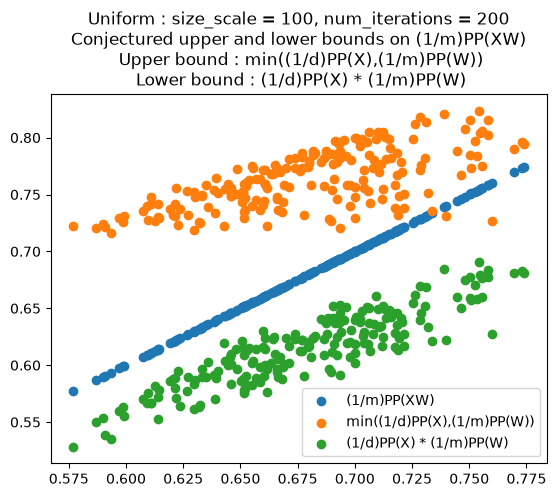

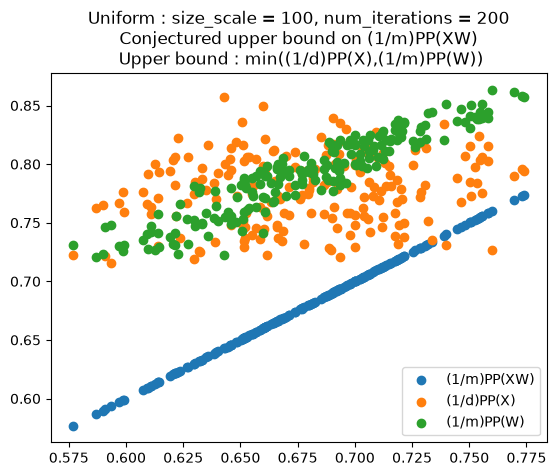


 (1/m) PP(XW) / ((1/d) PP(X) * (1/m) PP(W)) 
shape : (200,)
min : 1.0382142662792018
max : 1.2112856388260267
sum : 220.59023341889798
mean : 1.1029511670944898
std : 0.03168453937138053
norm : 15.604519774925944


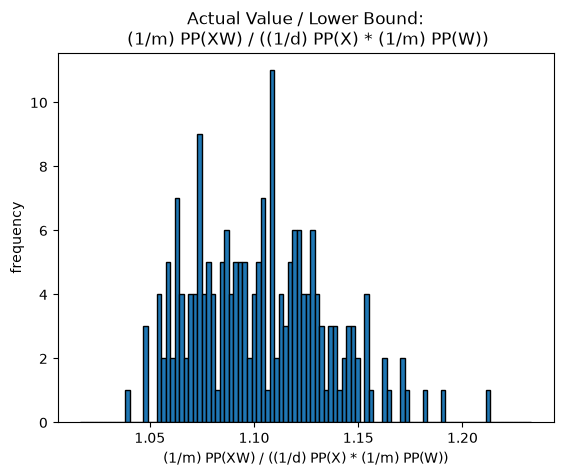


 min{(1/d)PP(X),(1/m)PP(W)} / (1/m) PP(XW) 
shape : (200,)
min : 0.955965888001921
max : 1.2527267770227997
sum : 225.32705541263695
mean : 1.1266352770631847
std : 0.05405281823370983
norm : 15.951355771107643


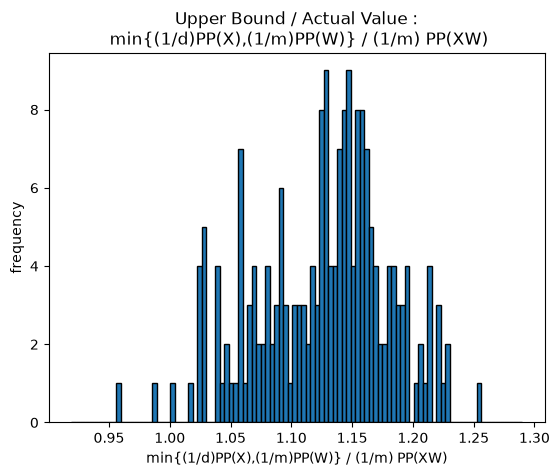

In [14]:
this_prefix = "Uniform : size_scale = " + str(size_scale) + ", num_iterations = " + str(num_iterations) + "\n"
pp_dim_XW_experiment_plot_one(xx_u_ss_100_ni_200, this_prefix)

# Test: switch off the column-demeaning

In [15]:
this_config = pp.pp_dim_XW_experiment_get_default_config()

num_iterations = 200
size_scale = 100

this_config["num_iterations"] = num_iterations 
this_config["use_uniform"] = True 
this_config["size_scale"] = size_scale 
this_config["column_demean"] = False 

xx_u_ss_100_ni_200_no_col_dem = pp.pp_dim_XW_experiment(this_config)

0 N =  216 , d =  202 , m =  193
using uniform
** calculate_nu_cpu ** running on CPU
0 X.shape =  (216, 202) , dim_X =  202
** calculate_nu_cpu ** running on CPU
0 W.shape =  (202, 193) , dim_W =  193
** calculate_nu_cpu ** running on CPU
0 XW.shape =  (216, 193) , dim_XW =  193
0 0.34974426304978 3.8756525540216904
0 PP(XW) =  36.43214355734422 , Tr(XW)^2 / Tr( (XW)^t (XW)) =  0.8911478005539675
1 N =  348 , d =  270 , m =  191
using uniform
** calculate_nu_cpu ** running on CPU
1 X.shape =  (348, 270) , dim_X =  270
** calculate_nu_cpu ** running on CPU
1 W.shape =  (270, 191) , dim_W =  191
** calculate_nu_cpu ** running on CPU
1 XW.shape =  (348, 191) , dim_XW =  191
1 0.3394009885293632 3.6270276722219346
1 PP(XW) =  41.75522979410929 , Tr(XW)^2 / Tr( (XW)^t (XW)) =  0.5456805404811842
2 N =  347 , d =  248 , m =  199
using uniform
** calculate_nu_cpu ** running on CPU
2 X.shape =  (347, 248) , dim_X =  248
** calculate_nu_cpu ** running on CPU
2 W.shape =  (248, 199) , dim_W =  1

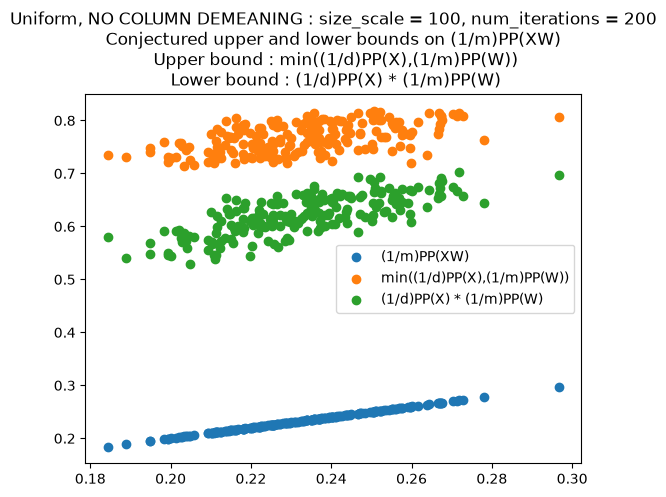

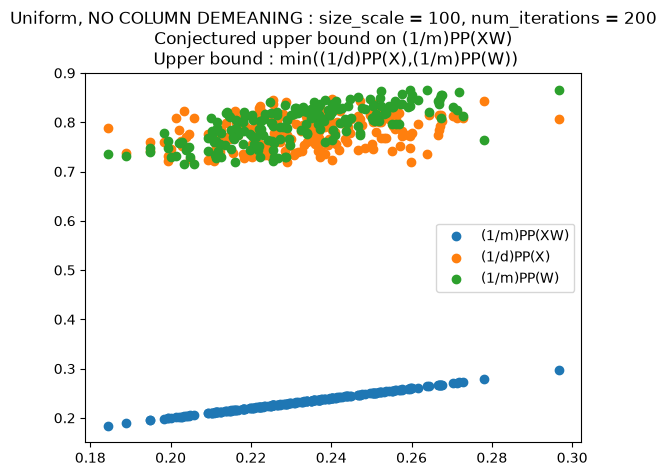


 (1/m) PP(XW) / ((1/d) PP(X) * (1/m) PP(W)) 
shape : (200,)
min : 0.31817694375577266
max : 0.4320734806892902
sum : 74.91979129229503
mean : 0.3745989564614752
std : 0.02077259569061628
norm : 5.305768161421151


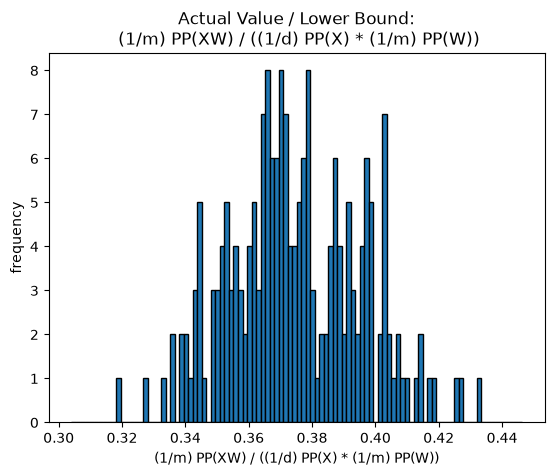


 min{(1/d)PP(X),(1/m)PP(W)} / (1/m) PP(XW) 
shape : (200,)
min : 2.71804336698768
max : 3.9888559314396774
sum : 662.0421162700839
mean : 3.3102105813504195
std : 0.23447022241083326
norm : 46.930737002697214


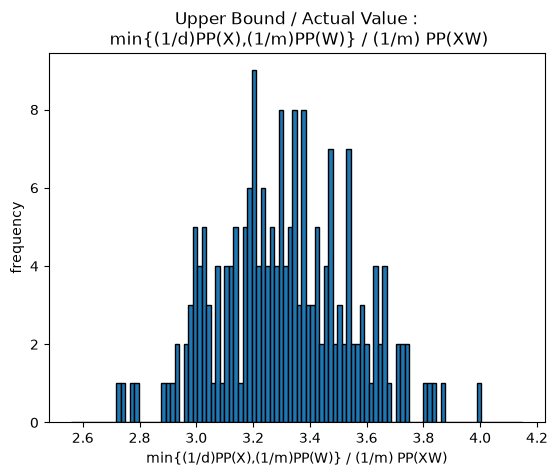

In [16]:
this_prefix = "Uniform, NO COLUMN DEMEANING : size_scale = " + str(size_scale) + ", num_iterations = " + str(num_iterations) + "\n"
pp_dim_XW_experiment_plot_one(xx_u_ss_100_ni_200_no_col_dem, this_prefix)

# 1.2 Normal - with column demeaning

In [17]:
this_config = pp.pp_dim_XW_experiment_get_default_config()

num_iterations = 200
size_scale = 100

this_config["num_iterations"] = num_iterations 
this_config["use_normal"] = True 
this_config["size_scale"] = size_scale

xx_normal_ss_100_ni_200 = pp.pp_dim_XW_experiment(this_config)

0 N =  371 , d =  272 , m =  198
using normal
** calculate_nu_cpu ** running on CPU
0 X.shape =  (371, 272) , dim_X =  272
** calculate_nu_cpu ** running on CPU
0 W.shape =  (272, 198) , dim_W =  198
** calculate_nu_cpu ** running on CPU
0 XW.shape =  (371, 198) , dim_XW =  198
0 1.0927951097332105 1.1375808900738915
0 PP(XW) =  139.61709956842128 , Tr(XW)^2 / Tr( (XW)^t (XW)) =  0.00010884362415924335
1 N =  243 , d =  226 , m =  197
using normal
** calculate_nu_cpu ** running on CPU
1 X.shape =  (243, 226) , dim_X =  226
** calculate_nu_cpu ** running on CPU
1 W.shape =  (226, 197) , dim_W =  197
** calculate_nu_cpu ** running on CPU
1 XW.shape =  (243, 197) , dim_XW =  197
1 1.10076754004472 1.193785167697335
1 PP(XW) =  122.37732513584646 , Tr(XW)^2 / Tr( (XW)^t (XW)) =  0.004692637517904642
2 N =  233 , d =  148 , m =  116
using normal
** calculate_nu_cpu ** running on CPU
2 X.shape =  (233, 148) , dim_X =  148
** calculate_nu_cpu ** running on CPU
2 W.shape =  (148, 116) , dim_W 

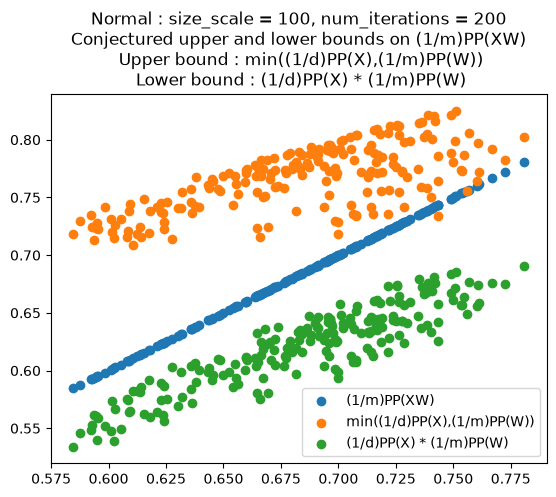

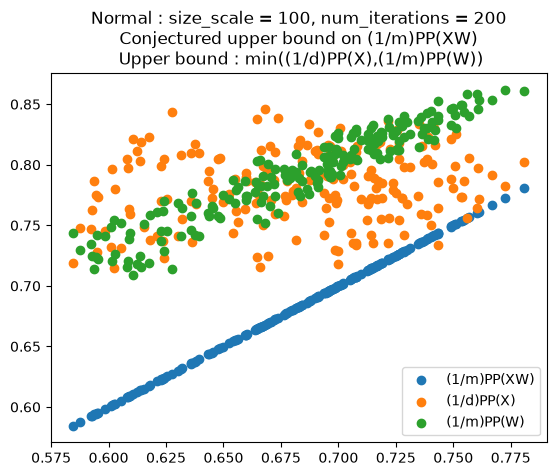


 (1/m) PP(XW) / ((1/d) PP(X) * (1/m) PP(W)) 
shape : (200,)
min : 1.0412012280779754
max : 1.1884455144433461
sum : 220.60705361045154
mean : 1.1030352680522577
std : 0.03205668510406693
norm : 15.605860653145518


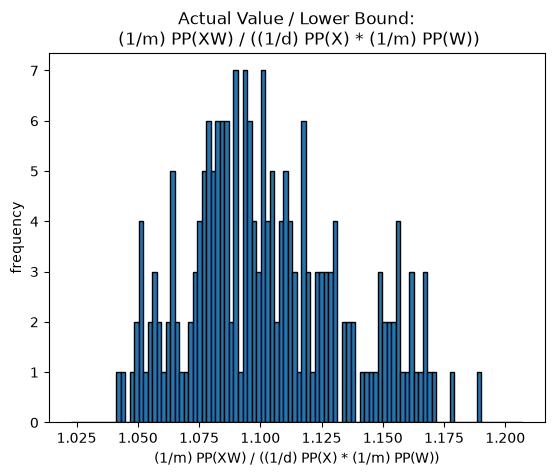


 min{(1/d)PP(X),(1/m)PP(W)} / (1/m) PP(XW) 
shape : (200,)
min : 0.9870660678564196
max : 1.240903018837538
sum : 224.73041405692874
mean : 1.1236520702846438
std : 0.05697906617826248
norm : 15.911257580955144


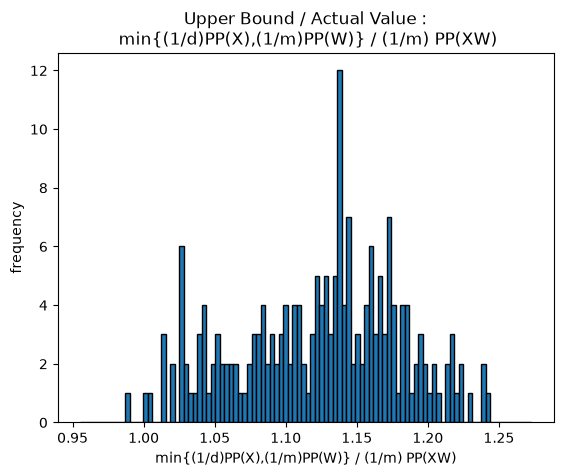

In [18]:
this_prefix = "Normal : size_scale = " + str(size_scale) + ", num_iterations = " + str(num_iterations) + "\n"
pp_dim_XW_experiment_plot_one(xx_normal_ss_100_ni_200, this_prefix)

# 1.2 Normal - no column demeaning
# this has much less effect than for uniform, because the matrix entries are iid normal with mean zero - so columns are already very close to demeaned

In [19]:
this_config = pp.pp_dim_XW_experiment_get_default_config()

num_iterations = 200
size_scale = 100

this_config["num_iterations"] = num_iterations 
this_config["use_normal"] = True 
this_config["size_scale"] = size_scale
this_config["column_demean"] = False

xx_normal_ss_100_ni_200_no_col_dem = pp.pp_dim_XW_experiment(this_config)

0 N =  344 , d =  253 , m =  159
using normal
** calculate_nu_cpu ** running on CPU
0 X.shape =  (344, 253) , dim_X =  253
** calculate_nu_cpu ** running on CPU
0 W.shape =  (253, 159) , dim_W =  159
** calculate_nu_cpu ** running on CPU
0 XW.shape =  (344, 159) , dim_XW =  159
0 1.1151307488194027 1.0745225305104975
0 PP(XW) =  118.63232827077987 , Tr(XW)^2 / Tr( (XW)^t (XW)) =  0.016404925772428393
1 N =  218 , d =  151 , m =  107
using normal
** calculate_nu_cpu ** running on CPU
1 X.shape =  (218, 151) , dim_X =  151
** calculate_nu_cpu ** running on CPU
1 W.shape =  (151, 107) , dim_W =  107
** calculate_nu_cpu ** running on CPU
1 XW.shape =  (218, 107) , dim_XW =  107
1 1.0853143761078043 1.1332647741526747
1 PP(XW) =  76.22388947160876 , Tr(XW)^2 / Tr( (XW)^t (XW)) =  0.028691647820694298
2 N =  176 , d =  149 , m =  139
using normal
** calculate_nu_cpu ** running on CPU
2 X.shape =  (176, 149) , dim_X =  149
** calculate_nu_cpu ** running on CPU
2 W.shape =  (149, 139) , dim_W 

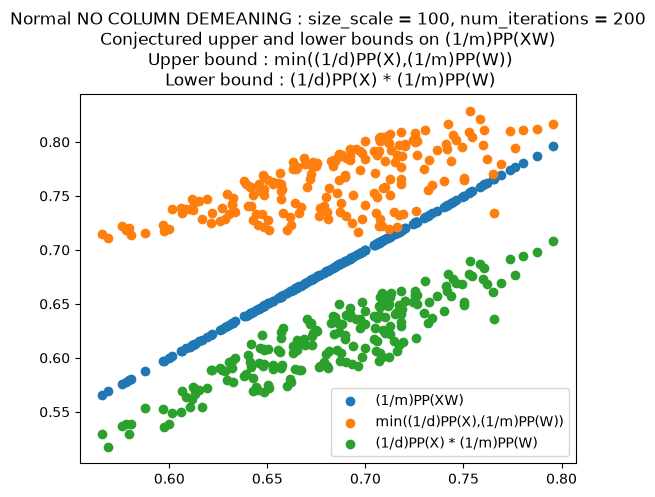

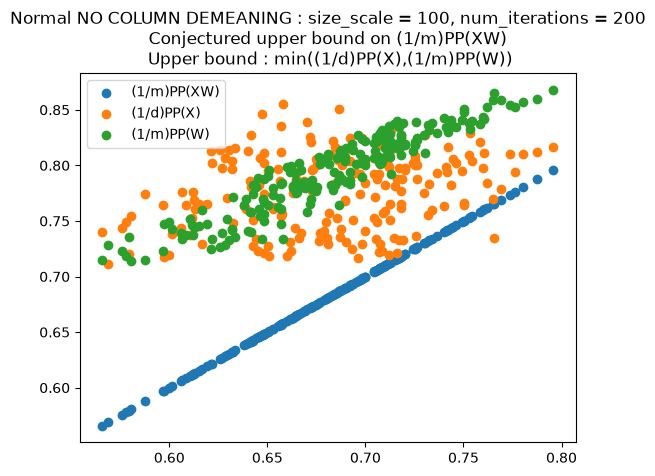


 (1/m) PP(XW) / ((1/d) PP(X) * (1/m) PP(W)) 
shape : (200,)
min : 1.0419516956333859
max : 1.2042538867730426
sum : 221.3870256816823
mean : 1.1069351284084115
std : 0.033175547454095365
norm : 15.66145584199263


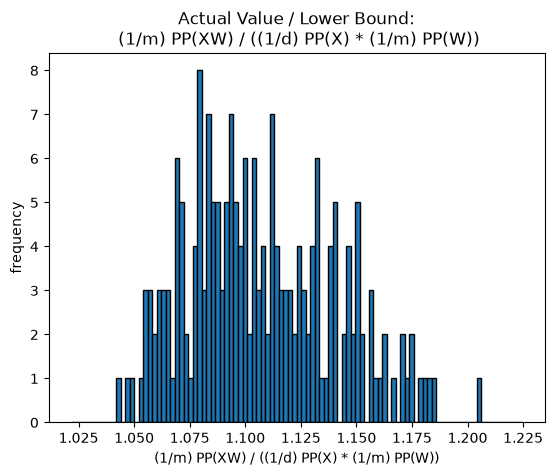


 min{(1/d)PP(X),(1/m)PP(W)} / (1/m) PP(XW) 
shape : (200,)
min : 0.9593664610193038
max : 1.2635390021742374
sum : 224.25015037746584
mean : 1.1212507518873291
std : 0.05938761346592492
norm : 15.879106632560152


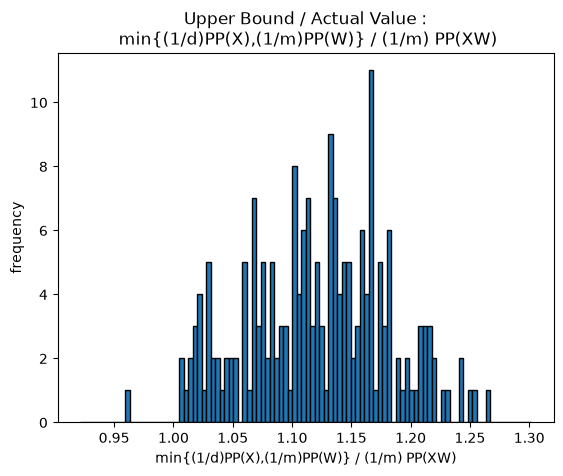

In [20]:
this_prefix = "Normal NO COLUMN DEMEANING : size_scale = " + str(size_scale) + ", num_iterations = " + str(num_iterations) + "\n"
pp_dim_XW_experiment_plot_one(xx_normal_ss_100_ni_200_no_col_dem, this_prefix)

# 1.3 Pareto - X_alpha = 1.15, W_alpha = 1.15

In [9]:
this_config = pp.pp_dim_XW_experiment_get_default_config()

num_iterations = 200
size_scale = 100

X_alpha = 1.15
W_alpha = 1.15

pareto_X_alpha_vals = X_alpha * np.ones(num_iterations)
pareto_W_alpha_vals = W_alpha * np.ones(num_iterations)

this_config["num_iterations"] = num_iterations 
this_config["use_normal"] = True 
this_config["size_scale"] = size_scale
#this_config["column_demean"] = False

this_config["pareto_X_alpha_vals"] = pareto_X_alpha_vals
this_config["pareto_W_alpha_vals"] = pareto_W_alpha_vals

xx_pareto_x_a_115_w_a_115_ss_100_ni_200 = pp.pp_dim_XW_experiment(this_config)

0 N =  242 , d =  198 , m =  114
using normal
** calculate_nu_cpu ** running on CPU
0 X.shape =  (242, 198) , dim_X =  198
** calculate_nu_cpu ** running on CPU
0 W.shape =  (198, 114) , dim_W =  114
** calculate_nu_cpu ** running on CPU
0 XW.shape =  (242, 114) , dim_XW =  114
0 1.1432566608662529 1.0318986422949123
0 PP(XW) =  85.81492175107135 , Tr(XW)^2 / Tr( (XW)^t (XW)) =  0.003308329006472712
1 N =  286 , d =  204 , m =  159
using normal
** calculate_nu_cpu ** running on CPU
1 X.shape =  (286, 204) , dim_X =  204
** calculate_nu_cpu ** running on CPU
1 W.shape =  (204, 159) , dim_W =  159
** calculate_nu_cpu ** running on CPU
1 XW.shape =  (286, 159) , dim_XW =  159
1 1.080689155968731 1.1481952090156022
1 PP(XW) =  109.1036495254762 , Tr(XW)^2 / Tr( (XW)^t (XW)) =  0.0004560858571730277
2 N =  241 , d =  151 , m =  143
using normal
** calculate_nu_cpu ** running on CPU
2 X.shape =  (241, 151) , dim_X =  151
** calculate_nu_cpu ** running on CPU
2 W.shape =  (151, 143) , dim_W =

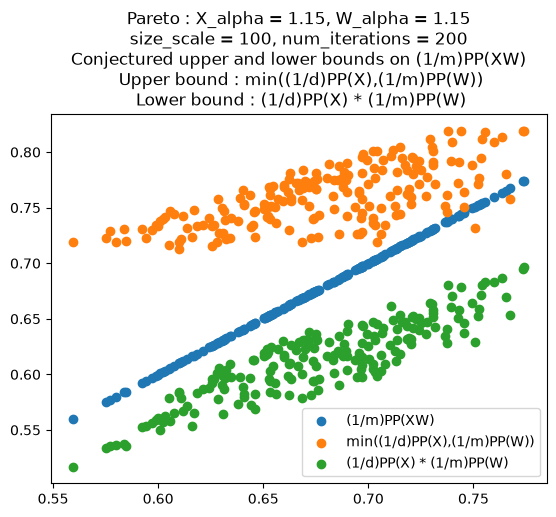

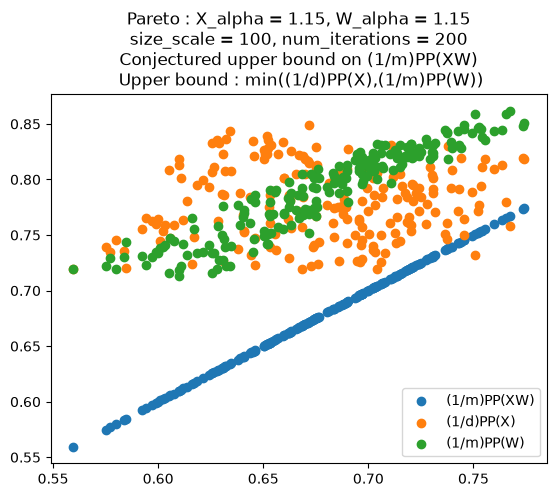


 (1/m) PP(XW) / ((1/d) PP(X) * (1/m) PP(W)) 
shape : (200,)
min : 1.0382567692722318
max : 1.194239951103287
sum : 220.52973190941648
mean : 1.1026486595470824
std : 0.03563247904110951
norm : 15.601946929557172


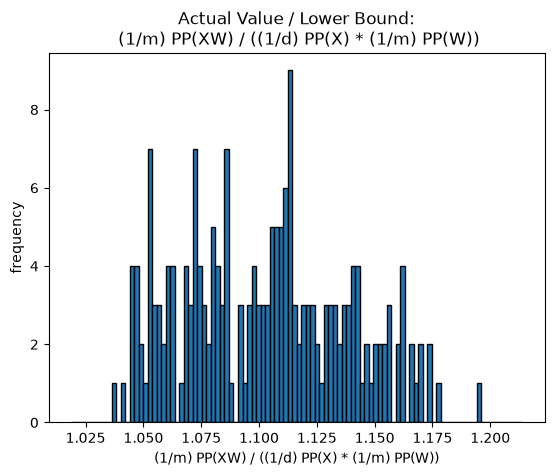


 min{(1/d)PP(X),(1/m)PP(W)} / (1/m) PP(XW) 
shape : (200,)
min : 0.9750156164719219
max : 1.2848664837527681
sum : 224.8055811341294
mean : 1.124027905670647
std : 0.05899098715750373
norm : 15.918031720612682


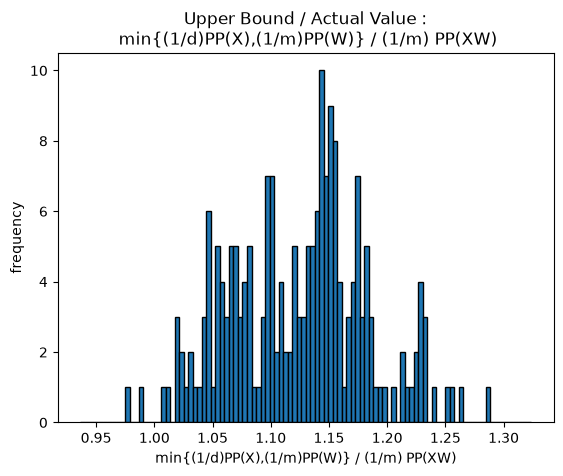

In [10]:
this_prefix = "Pareto : X_alpha = " + str(X_alpha) + ", W_alpha = " + str(W_alpha) + "\n"
this_prefix += "size_scale = " + str(size_scale) + ", num_iterations = " + str(num_iterations) + "\n"
pp_dim_XW_experiment_plot_one(xx_pareto_x_a_115_w_a_115_ss_100_ni_200, this_prefix)

# 1.3 Pareto - X_alpha = 1.15, W_alpha = 1.15 - no column demeaning

In [3]:
this_config = pp.pp_dim_XW_experiment_get_default_config()

num_iterations = 200
size_scale = 100

X_alpha = 1.15
W_alpha = 1.15

pareto_X_alpha_vals = X_alpha * np.ones(num_iterations)
pareto_W_alpha_vals = W_alpha * np.ones(num_iterations)

this_config["num_iterations"] = num_iterations 
this_config["use_pareto"] = True 
this_config["size_scale"] = size_scale
this_config["column_demean"] = False

this_config["pareto_X_alpha_vals"] = pareto_X_alpha_vals
this_config["pareto_W_alpha_vals"] = pareto_W_alpha_vals

xx_pareto_x_a_115_w_a_115_ss_100_ni_200_no_col_dem = pp.pp_dim_XW_experiment(this_config)

0 N =  305 , d =  232 , m =  137
using Pareto
** calculate_nu_cpu ** running on CPU
0 X.shape =  (305, 232) , dim_X =  232
** calculate_nu_cpu ** running on CPU
0 W.shape =  (232, 137) , dim_W =  137
** calculate_nu_cpu ** running on CPU
0 XW.shape =  (305, 137) , dim_XW =  137
0 1.6572682324769215 1.7466232300349733
0 PP(XW) =  23.468695436233606 , Tr(XW)^2 / Tr( (XW)^t (XW)) =  0.02722056641828817
1 N =  254 , d =  207 , m =  108
using Pareto
** calculate_nu_cpu ** running on CPU
1 X.shape =  (254, 207) , dim_X =  207
** calculate_nu_cpu ** running on CPU
1 W.shape =  (207, 108) , dim_W =  108
** calculate_nu_cpu ** running on CPU
1 XW.shape =  (254, 108) , dim_XW =  108
1 1.2440551176899612 2.4945191431684894
1 PP(XW) =  13.189868020628662 , Tr(XW)^2 / Tr( (XW)^t (XW)) =  0.02110943264537509
2 N =  258 , d =  215 , m =  121
using Pareto
** calculate_nu_cpu ** running on CPU
2 X.shape =  (258, 215) , dim_X =  215
** calculate_nu_cpu ** running on CPU
2 W.shape =  (215, 121) , dim_W =

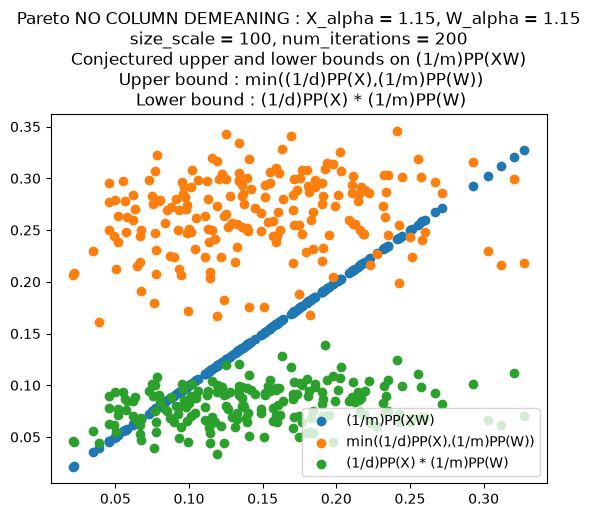

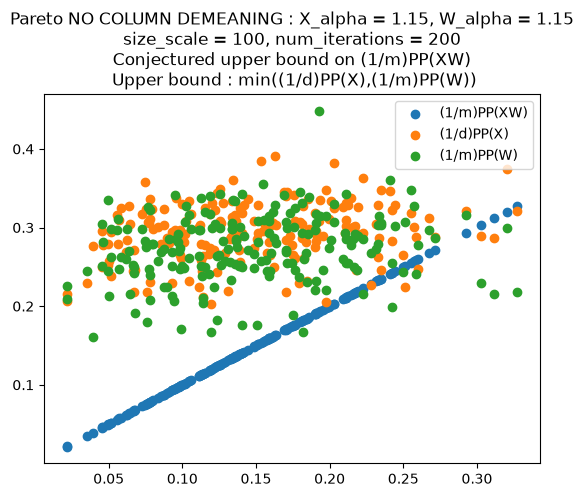


 (1/m) PP(XW) / ((1/d) PP(X) * (1/m) PP(W)) 
shape : (200,)
min : 0.46044937176760037
max : 5.0376922237169754
sum : 376.10416686210306
mean : 1.8805208343105153
std : 0.8888857927843055
norm : 29.41590236892181


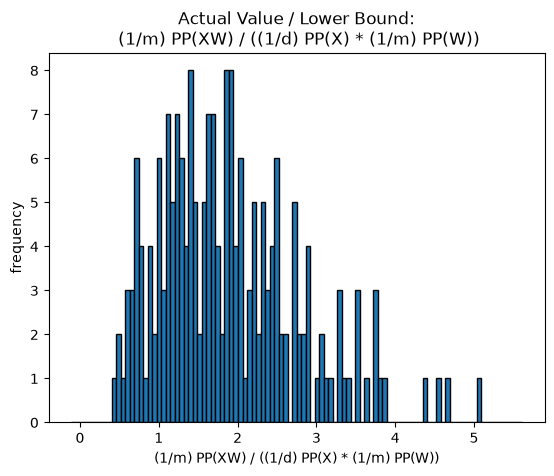


 min{(1/d)PP(X),(1/m)PP(W)} / (1/m) PP(XW) 
shape : (200,)
min : 0.6675893415883779
max : 9.636011368353149
sum : 452.9659081749054
mean : 2.264829540874527
std : 1.357845295070778
norm : 37.34487031591827


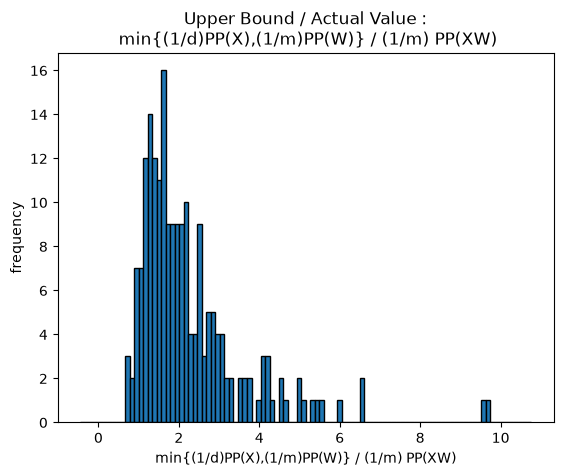

In [8]:
this_prefix = "Pareto NO COLUMN DEMEANING : X_alpha = " + str(X_alpha) + ", W_alpha = " + str(W_alpha) + "\n"
this_prefix += "size_scale = " + str(size_scale) + ", num_iterations = " + str(num_iterations) + "\n"
pp_dim_XW_experiment_plot_one(xx_pareto_x_a_115_w_a_115_ss_100_ni_200_no_col_dem, this_prefix)

# 1.3 Pareto - X_alpha = 1.15, W_alpha varies between 0.1 and 5.0

In [21]:
this_config = pp.pp_dim_XW_experiment_get_default_config()

num_iterations = 200
size_scale = 100

this_config["num_iterations"] = num_iterations 
this_config["use_pareto"] = True 
this_config["size_scale"] = size_scale
this_config["column_demean"] = True

X_alpha = 1.15
pareto_X_alpha_vals = X_alpha * np.ones(num_iterations)

min_W_alpha = 0.1
max_W_alpha = 5.0
pareto_W_alpha_vals = min_W_alpha * np.exp(math.log(max_W_alpha / min_W_alpha) * np.linspace(0, 1, num=num_iterations))

this_config["pareto_X_alpha_vals"] = pareto_X_alpha_vals
this_config["pareto_W_alpha_vals"] = pareto_W_alpha_vals

xx_pareto_x_a_115_w_a_01_50_ss_100_ni_200 = pp.pp_dim_XW_experiment(this_config)

0 N =  182 , d =  166 , m =  118
using Pareto
** calculate_nu_cpu ** running on CPU
0 X.shape =  (182, 166) , dim_X =  166
** calculate_nu_cpu ** running on CPU
0 W.shape =  (166, 118) , dim_W =  118
** calculate_nu_cpu ** running on CPU
0 XW.shape =  (182, 118) , dim_XW =  118
0 3.635568134638191 0.9935394591196683
0 PP(XW) =  3.937310771471896 , Tr(XW)^2 / Tr( (XW)^t (XW)) =  2.692585581240415e-06
1 N =  316 , d =  237 , m =  155
using Pareto
** calculate_nu_cpu ** running on CPU
1 X.shape =  (316, 237) , dim_X =  237
** calculate_nu_cpu ** running on CPU
1 W.shape =  (237, 155) , dim_W =  155
** calculate_nu_cpu ** running on CPU
1 XW.shape =  (316, 155) , dim_XW =  155
1 2.475428079949467 1.2716543627203825
1 PP(XW) =  2.3627032972313424 , Tr(XW)^2 / Tr( (XW)^t (XW)) =  0.00019915881664605585
2 N =  258 , d =  220 , m =  149
using Pareto
** calculate_nu_cpu ** running on CPU
2 X.shape =  (258, 220) , dim_X =  220
** calculate_nu_cpu ** running on CPU
2 W.shape =  (220, 149) , dim_W

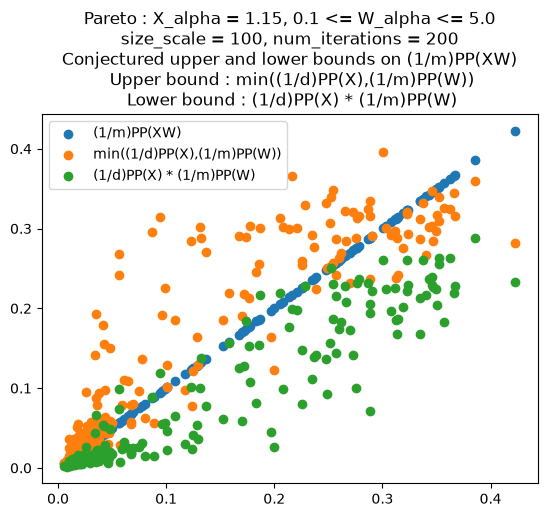

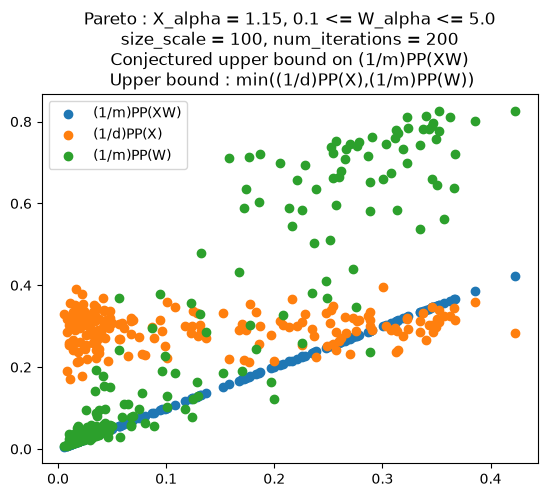


 (1/m) PP(XW) / ((1/d) PP(X) * (1/m) PP(W)) 
shape : (200,)
min : 0.5245719588283406
max : 7.599151017894549
sum : 455.7163654488443
mean : 2.2785818272442215
std : 1.2558331236410853
norm : 36.79416252038287


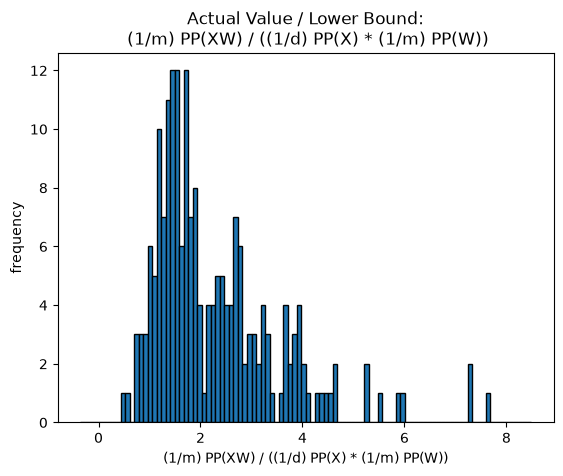


 min{(1/d)PP(X),(1/m)PP(W)} / (1/m) PP(XW) 
shape : (200,)
min : 0.5069251151581402
max : 5.510043528584861
sum : 288.90834412516074
mean : 1.4445417206258038
std : 0.7837494875383513
norm : 23.242048282564024


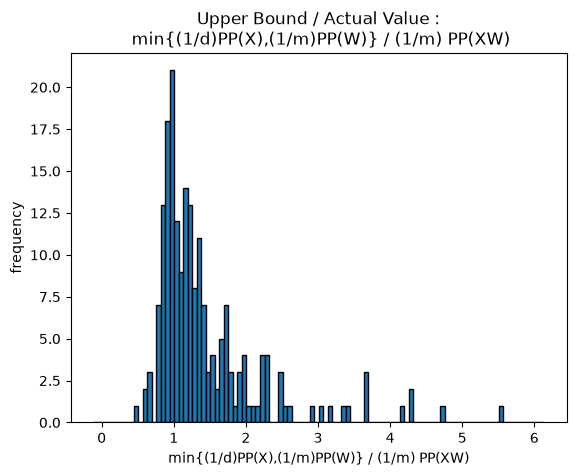

In [22]:
this_prefix = "Pareto : X_alpha = " + str(X_alpha) + ", " + str(min_W_alpha) + " <= W_alpha <= " + str(max_W_alpha) + "\n"
this_prefix += "size_scale = " + str(size_scale) + ", num_iterations = " + str(num_iterations) + "\n"
pp_dim_XW_experiment_plot_one(xx_pareto_x_a_115_w_a_01_50_ss_100_ni_200, this_prefix)

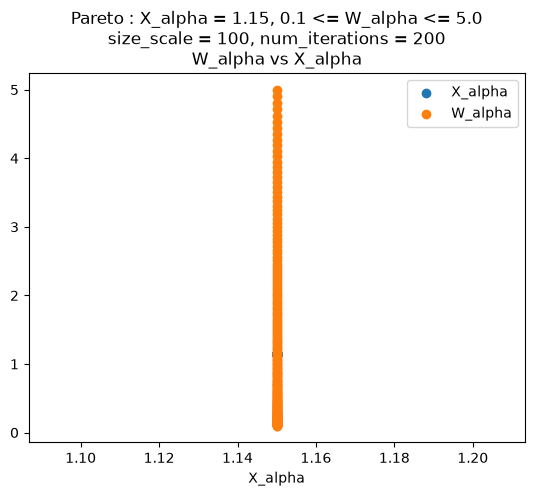

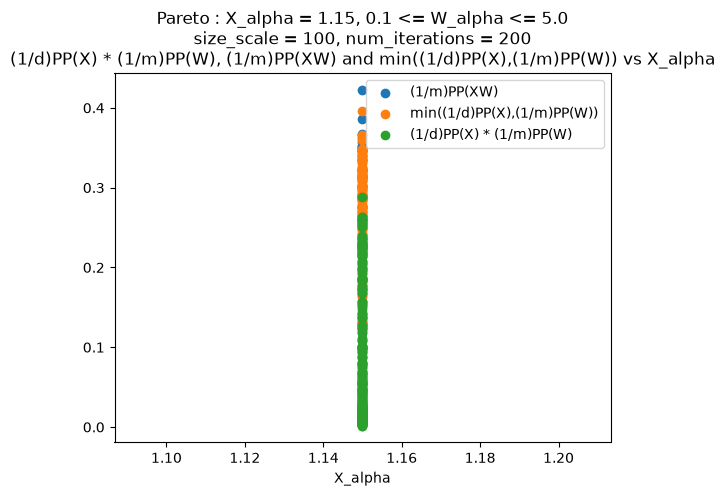

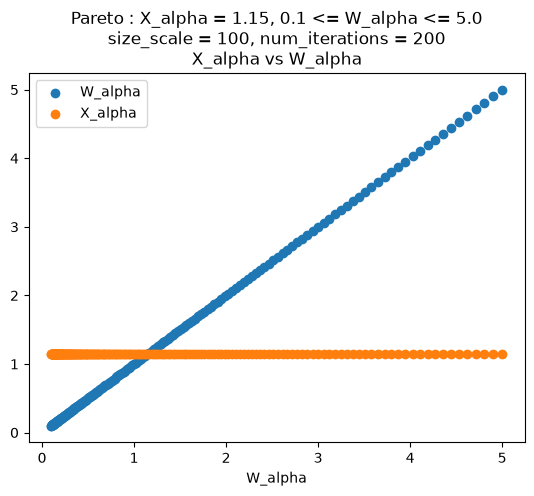

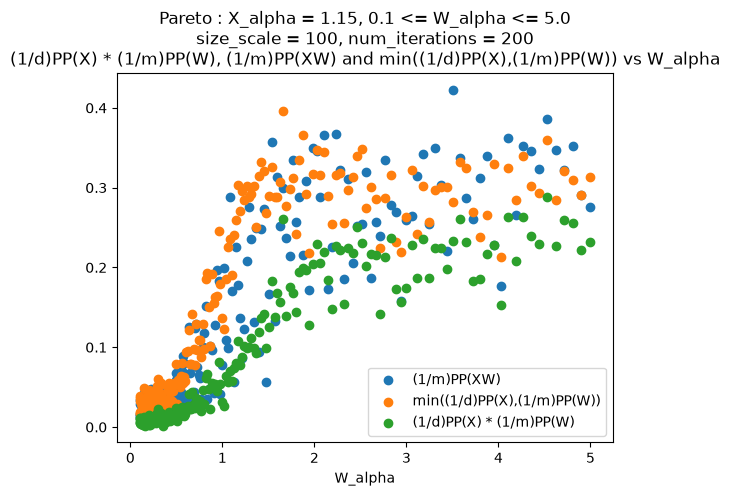

In [23]:
this_prefix = "Pareto : X_alpha = " + str(X_alpha) + ", " + str(min_W_alpha) + " <= W_alpha <= " + str(max_W_alpha) + "\n"
this_prefix += "size_scale = " + str(size_scale) + ", num_iterations = " + str(num_iterations) + "\n"
xx_pareto_x_a_115_w_a_01_50_ss_100_ni_200["plt_vs_X_alpha"] = True
xx_pareto_x_a_115_w_a_01_50_ss_100_ni_200["plt_vs_W_alpha"] = True
pp_dim_XW_experiment_pareto_plot(xx_pareto_x_a_115_w_a_01_50_ss_100_ni_200, this_prefix)

# 1.3 Pareto - X_alpha = 1.15, W_alpha varies between 0.1 and 5.0 - uniform draws

In [3]:
this_config = pp.pp_dim_XW_experiment_get_default_config()

num_iterations = 200
size_scale = 100

this_config["num_iterations"] = num_iterations 
this_config["use_pareto"] = True 
this_config["size_scale"] = size_scale
this_config["column_demean"] = True

X_alpha = 1.15
pareto_X_alpha_vals = X_alpha * np.ones(num_iterations)

min_W_alpha = 0.1
max_W_alpha = 5.0
pareto_W_alpha_vals = min_W_alpha * np.exp(math.log(max_W_alpha / min_W_alpha) * np.linspace(0, 1, num=num_iterations))

this_config["pareto_X_alpha_vals"] = pareto_X_alpha_vals
this_config["pareto_W_alpha_vals"] = pareto_W_alpha_vals
this_config["pareto_uniform_draws"] = True

xx_pareto_udraws_x_a_115_w_a_01_50_ss_100_ni_200 = pp.pp_dim_XW_experiment(this_config)

0 N =  305 , d =  232 , m =  137
using Pareto
** calculate_nu_cpu ** running on CPU
0 X.shape =  (305, 232) , dim_X =  232
** calculate_nu_cpu ** running on CPU
0 W.shape =  (232, 137) , dim_W =  137
** calculate_nu_cpu ** running on CPU
0 XW.shape =  (305, 137) , dim_XW =  137
0 179.9040902803915 0.7615168714978705
0 PP(XW) =  1.0000000000000306 , Tr(XW)^2 / Tr( (XW)^t (XW)) =  3.6960405586338906e-05
1 N =  189 , d =  174 , m =  159
using Pareto
** calculate_nu_cpu ** running on CPU
1 X.shape =  (189, 174) , dim_X =  174
** calculate_nu_cpu ** running on CPU
1 W.shape =  (174, 159) , dim_W =  159
** calculate_nu_cpu ** running on CPU
1 XW.shape =  (189, 159) , dim_XW =  159
1 138.1655752089261 0.9999999999999876
1 PP(XW) =  1.00000000000006 , Tr(XW)^2 / Tr( (XW)^t (XW)) =  8.108554417436417e-05
2 N =  251 , d =  191 , m =  105
using Pareto
** calculate_nu_cpu ** running on CPU
2 X.shape =  (251, 191) , dim_X =  191
** calculate_nu_cpu ** running on CPU
2 W.shape =  (191, 105) , dim_W 

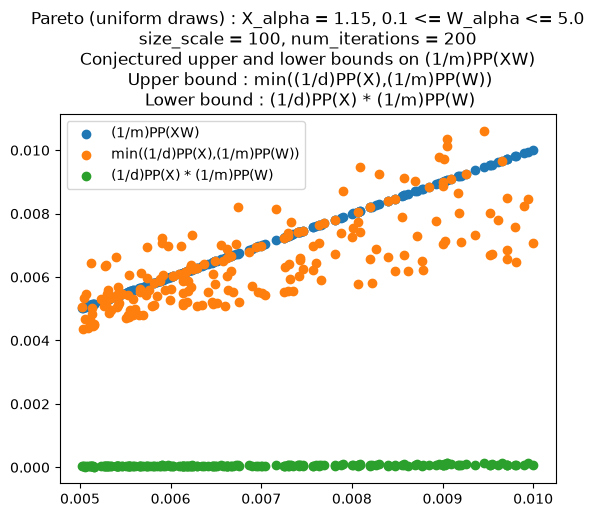

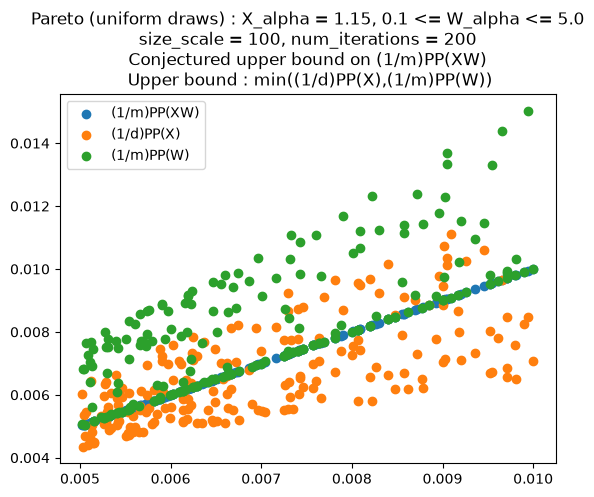


 (1/m) PP(XW) / ((1/d) PP(X) * (1/m) PP(W)) 
shape : (200,)
min : 63.99620497751006
max : 223.02656079638223
sum : 27616.915761983895
mean : 138.08457880991946
std : 34.22578816256261
norm : 2011.9023574945913


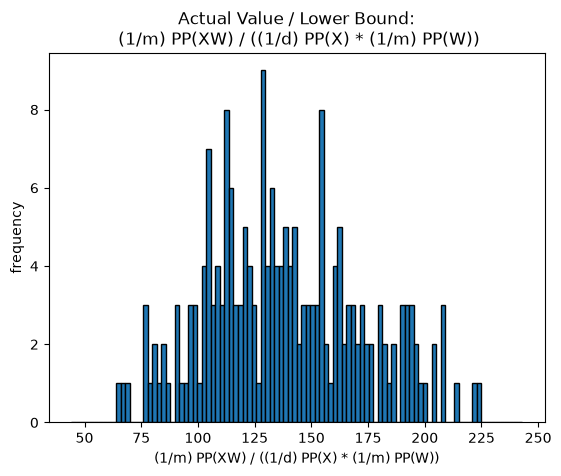


 min{(1/d)PP(X),(1/m)PP(W)} / (1/m) PP(XW) 
shape : (200,)
min : 0.6618423461075609
max : 1.2572818694603416
sum : 187.26480150432087
mean : 0.9363240075216044
std : 0.12298987677280797
norm : 13.355367137221709


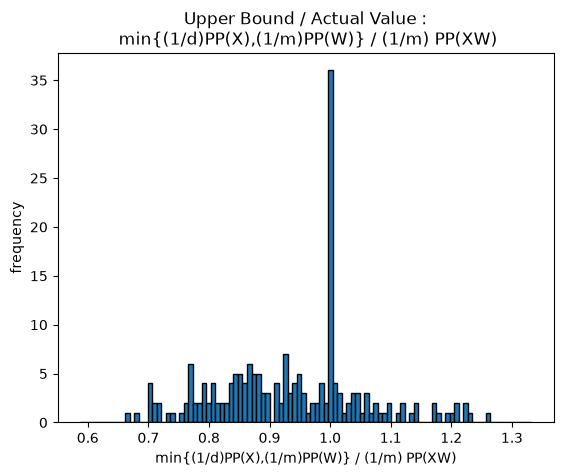

In [9]:
this_prefix = "Pareto (uniform draws) : X_alpha = " + str(X_alpha) + ", " + str(min_W_alpha) + " <= W_alpha <= " + str(max_W_alpha) + "\n"
this_prefix += "size_scale = " + str(size_scale) + ", num_iterations = " + str(num_iterations) + "\n"
pp_dim_XW_experiment_plot_one(xx_pareto_udraws_x_a_115_w_a_01_50_ss_100_ni_200, this_prefix)

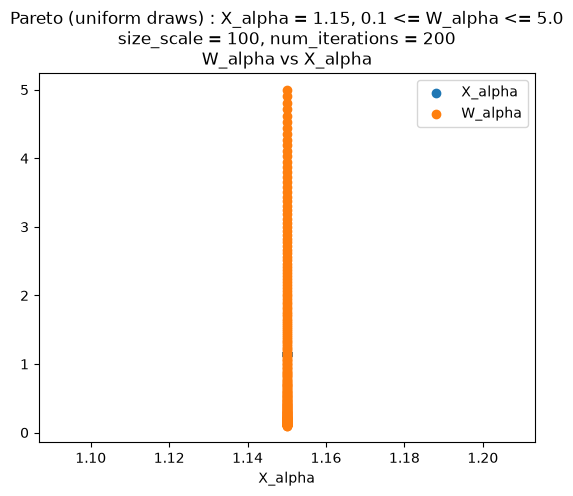

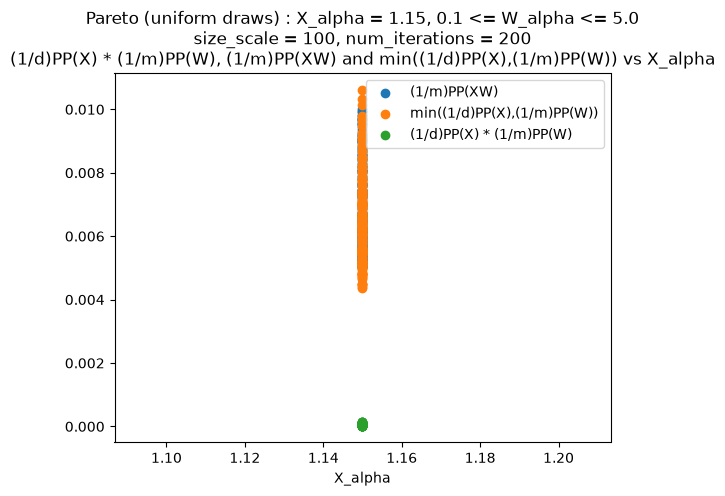

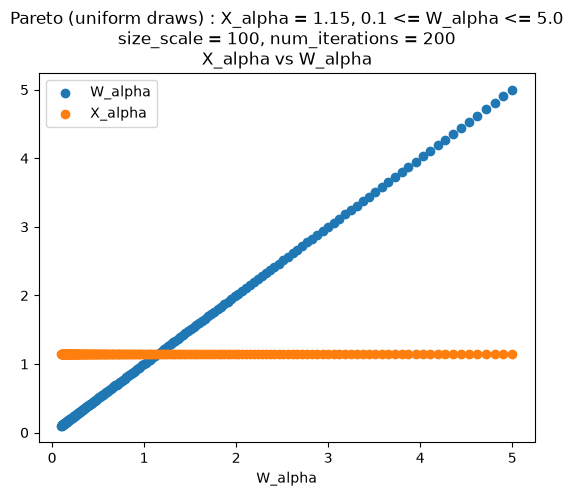

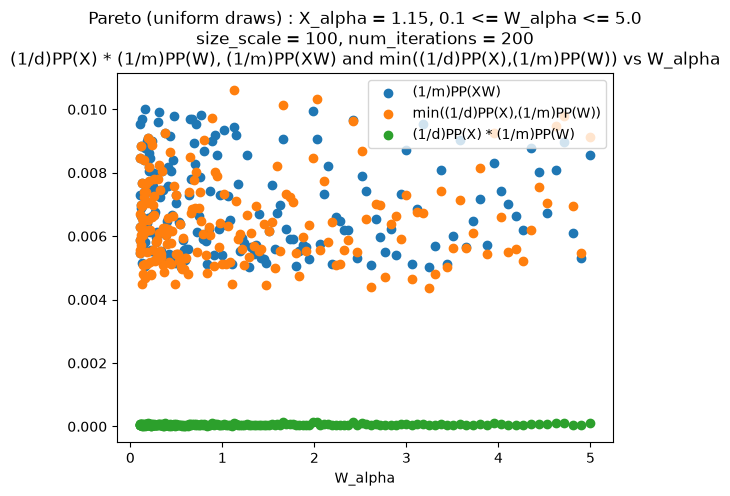

In [8]:
this_prefix = "Pareto (uniform draws) : X_alpha = " + str(X_alpha) + ", " + str(min_W_alpha) + " <= W_alpha <= " + str(max_W_alpha) + "\n"
this_prefix += "size_scale = " + str(size_scale) + ", num_iterations = " + str(num_iterations) + "\n"
xx_pareto_udraws_x_a_115_w_a_01_50_ss_100_ni_200["plt_vs_X_alpha"] = True
xx_pareto_udraws_x_a_115_w_a_01_50_ss_100_ni_200["plt_vs_W_alpha"] = True
pp_dim_XW_experiment_pareto_plot(xx_pareto_udraws_x_a_115_w_a_01_50_ss_100_ni_200, this_prefix)

# 1.3 Pareto - X_alpha = 3.0, W_alpha varies between 0.1 and 5.0 - no uniform draws

In [13]:
this_config = pp.pp_dim_XW_experiment_get_default_config()

num_iterations = 200
size_scale = 100

this_config["num_iterations"] = num_iterations 
this_config["use_pareto"] = True 
this_config["size_scale"] = size_scale
this_config["column_demean"] = True

X_alpha = 3.0
pareto_X_alpha_vals = X_alpha * np.ones(num_iterations)

min_W_alpha = 0.1
max_W_alpha = 5.0
pareto_W_alpha_vals = min_W_alpha * np.exp(math.log(max_W_alpha / min_W_alpha) * np.linspace(0, 1, num=num_iterations))

this_config["pareto_X_alpha_vals"] = pareto_X_alpha_vals
this_config["pareto_W_alpha_vals"] = pareto_W_alpha_vals
this_config["pareto_uniform_draws"] = False

xx_pareto_no_ud_x_a_30_w_a_01_50_ss_100_ni_200 = pp.pp_dim_XW_experiment(this_config)

0 N =  251 , d =  158 , m =  105
using Pareto
** calculate_nu_cpu ** running on CPU
0 X.shape =  (251, 158) , dim_X =  158
** calculate_nu_cpu ** running on CPU
0 W.shape =  (158, 105) , dim_W =  105
** calculate_nu_cpu ** running on CPU
0 XW.shape =  (251, 105) , dim_XW =  105
0 1.2517948571182125 1.010083142583913
0 PP(XW) =  2.6697554892170423 , Tr(XW)^2 / Tr( (XW)^t (XW)) =  0.000562079430820508
1 N =  337 , d =  280 , m =  198
using Pareto
** calculate_nu_cpu ** running on CPU
1 X.shape =  (337, 280) , dim_X =  280
** calculate_nu_cpu ** running on CPU
1 W.shape =  (280, 198) , dim_W =  198
** calculate_nu_cpu ** running on CPU
1 XW.shape =  (337, 198) , dim_XW =  198
1 1.4514487083323047 0.9353931149271822
1 PP(XW) =  5.864946952561402 , Tr(XW)^2 / Tr( (XW)^t (XW)) =  0.0028108957034164842
2 N =  284 , d =  278 , m =  192
using Pareto
** calculate_nu_cpu ** running on CPU
2 X.shape =  (284, 278) , dim_X =  278
** calculate_nu_cpu ** running on CPU
2 W.shape =  (278, 192) , dim_W 

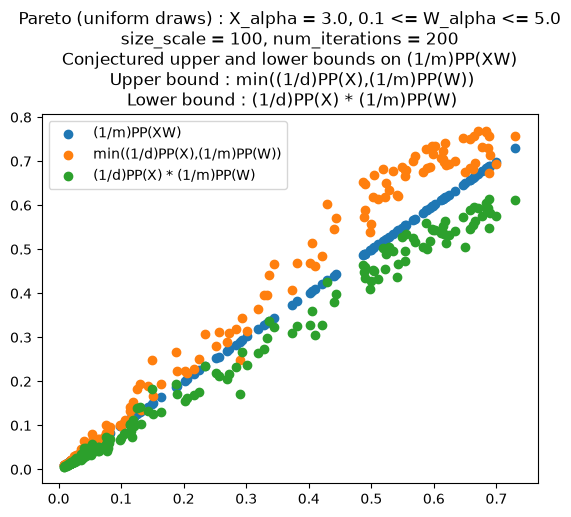

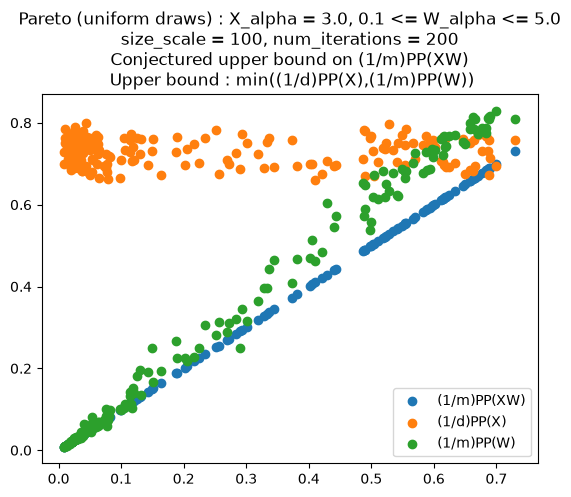


 (1/m) PP(XW) / ((1/d) PP(X) * (1/m) PP(W)) 
shape : (200,)
min : 0.8198071769186409
max : 1.8434185446638003
sum : 250.5454964323757
mean : 1.2527274821618786
std : 0.16180492890484607
norm : 17.86340941467525


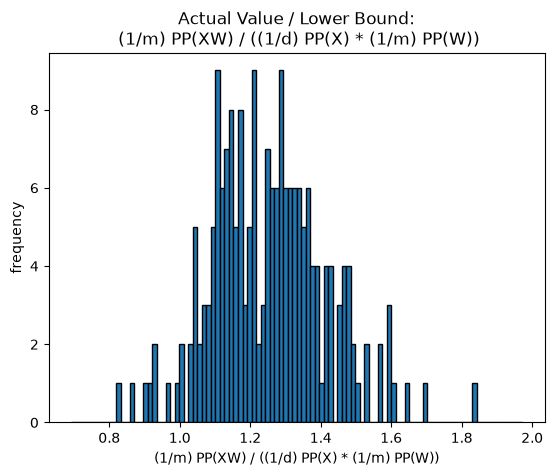


 min{(1/d)PP(X),(1/m)PP(W)} / (1/m) PP(XW) 
shape : (200,)
min : 0.7758622072426524
max : 1.6671376190833451
sum : 220.58471699487643
mean : 1.1029235849743821
std : 0.13700005266348136
norm : 15.717566279310164


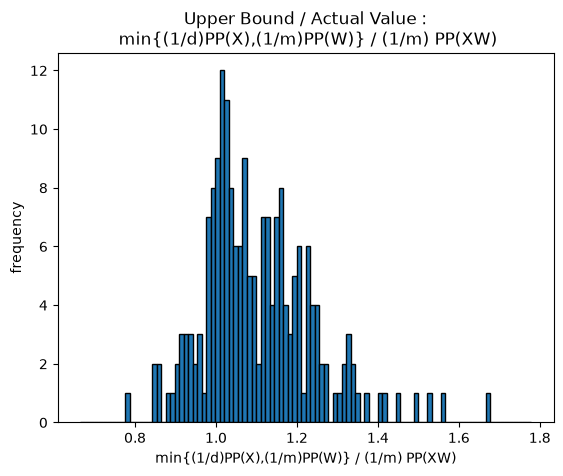

In [14]:
this_prefix = "Pareto (uniform draws) : X_alpha = " + str(X_alpha) + ", " + str(min_W_alpha) + " <= W_alpha <= " + str(max_W_alpha) + "\n"
this_prefix += "size_scale = " + str(size_scale) + ", num_iterations = " + str(num_iterations) + "\n"
pp_dim_XW_experiment_plot_one(xx_pareto_no_ud_x_a_30_w_a_01_50_ss_100_ni_200, this_prefix)

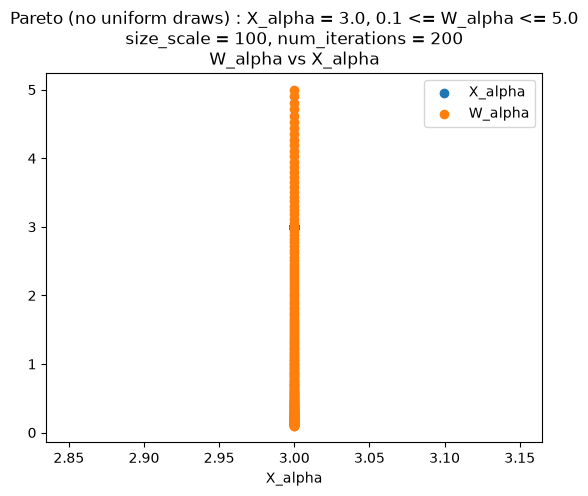

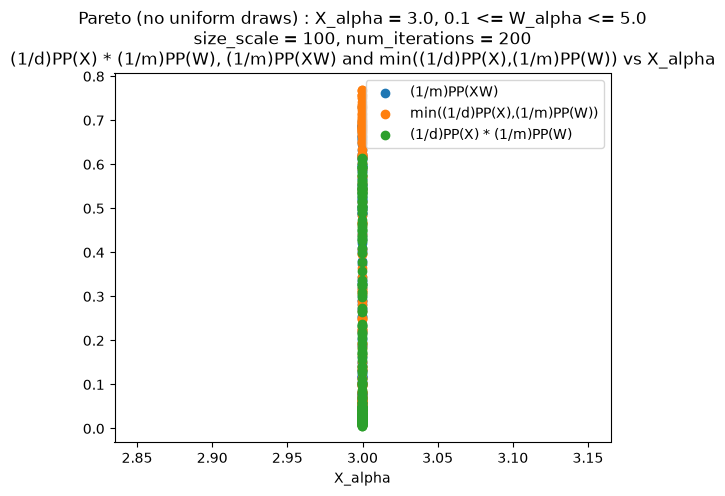

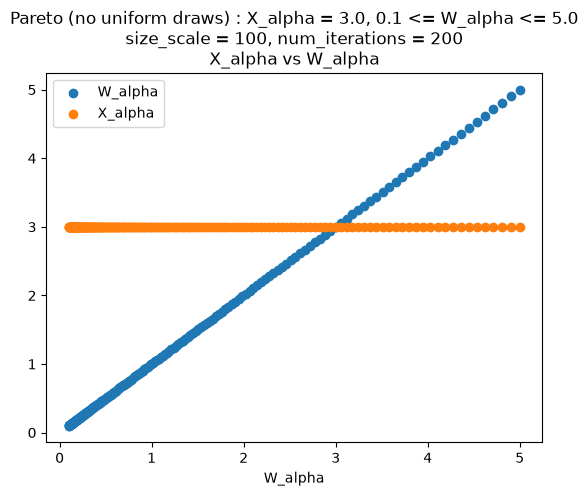

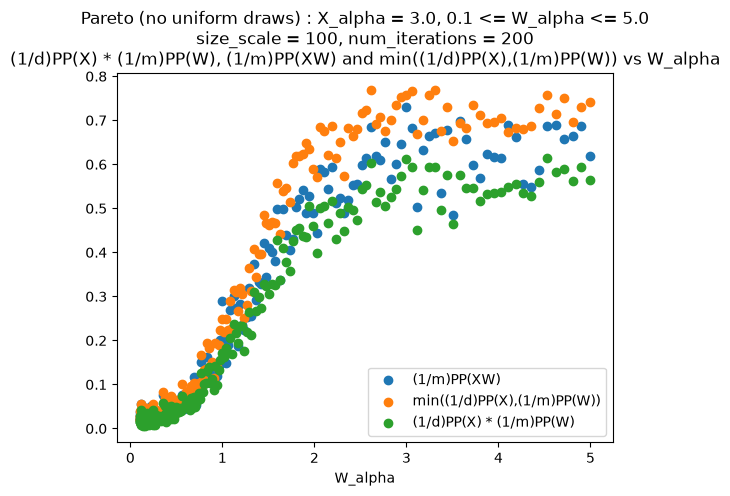

In [15]:
this_prefix = "Pareto (no uniform draws) : X_alpha = " + str(X_alpha) + ", " + str(min_W_alpha) + " <= W_alpha <= " + str(max_W_alpha) + "\n"
this_prefix += "size_scale = " + str(size_scale) + ", num_iterations = " + str(num_iterations) + "\n"
xx_pareto_no_ud_x_a_30_w_a_01_50_ss_100_ni_200["plt_vs_X_alpha"] = True
xx_pareto_no_ud_x_a_30_w_a_01_50_ss_100_ni_200["plt_vs_W_alpha"] = True
pp_dim_XW_experiment_pareto_plot(xx_pareto_no_ud_x_a_30_w_a_01_50_ss_100_ni_200, this_prefix)

# 1.3 Pareto - X_alpha varies between 0.1 and 5.0, W_alpha = 3.0 - no uniform draws

In [16]:
this_config = pp.pp_dim_XW_experiment_get_default_config()

num_iterations = 200
size_scale = 100

this_config["num_iterations"] = num_iterations 
this_config["use_pareto"] = True 
this_config["size_scale"] = size_scale
this_config["column_demean"] = True


min_X_alpha = 0.1
max_X_alpha = 5.0
pareto_X_alpha_vals = min_X_alpha * np.exp(math.log(max_X_alpha / min_X_alpha) * np.linspace(0, 1, num=num_iterations))
#X_alpha = 3.0
#pareto_X_alpha_vals = X_alpha * np.ones(num_iterations)

#min_W_alpha = 0.1
#max_W_alpha = 5.0
#pareto_W_alpha_vals = min_W_alpha * np.exp(math.log(max_W_alpha / min_W_alpha) * np.linspace(0, 1, num=num_iterations))
W_alpha = 3.0
pareto_W_alpha_vals = W_alpha * np.ones(num_iterations)

this_config["pareto_X_alpha_vals"] = pareto_X_alpha_vals
this_config["pareto_W_alpha_vals"] = pareto_W_alpha_vals
this_config["pareto_uniform_draws"] = False

xx_pareto_no_ud_x_a_01_50_w_a_30_ss_100_ni_200 = pp.pp_dim_XW_experiment(this_config)

0 N =  259 , d =  221 , m =  187
using Pareto
** calculate_nu_cpu ** running on CPU
0 X.shape =  (259, 221) , dim_X =  221
** calculate_nu_cpu ** running on CPU
0 W.shape =  (221, 187) , dim_W =  187
** calculate_nu_cpu ** running on CPU
0 XW.shape =  (259, 187) , dim_XW =  187
0 1.579000389297769 0.8886092993319992
0 PP(XW) =  8.725021223021958 , Tr(XW)^2 / Tr( (XW)^t (XW)) =  0.0017696524742764526
1 N =  181 , d =  133 , m =  104
using Pareto
** calculate_nu_cpu ** running on CPU
1 X.shape =  (181, 133) , dim_X =  133
** calculate_nu_cpu ** running on CPU
1 W.shape =  (133, 104) , dim_W =  104
** calculate_nu_cpu ** running on CPU
1 XW.shape =  (181, 104) , dim_XW =  104
1 1.6598202375882496 0.8224274170771794
1 PP(XW) =  1.9037172174175292 , Tr(XW)^2 / Tr( (XW)^t (XW)) =  0.00431168208153411
2 N =  302 , d =  213 , m =  192
using Pareto
** calculate_nu_cpu ** running on CPU
2 X.shape =  (302, 213) , dim_X =  213
** calculate_nu_cpu ** running on CPU
2 W.shape =  (213, 192) , dim_W =

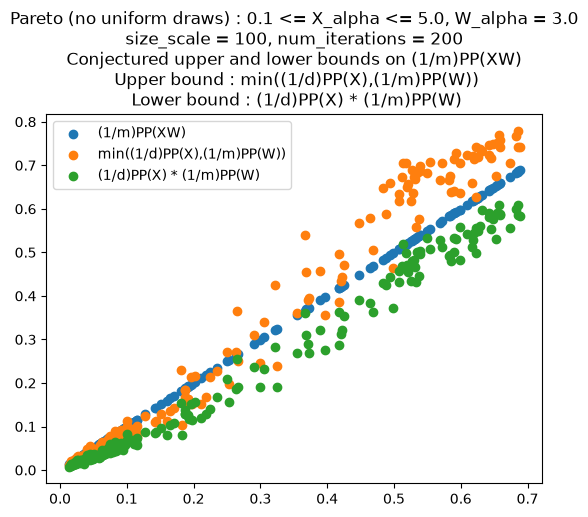

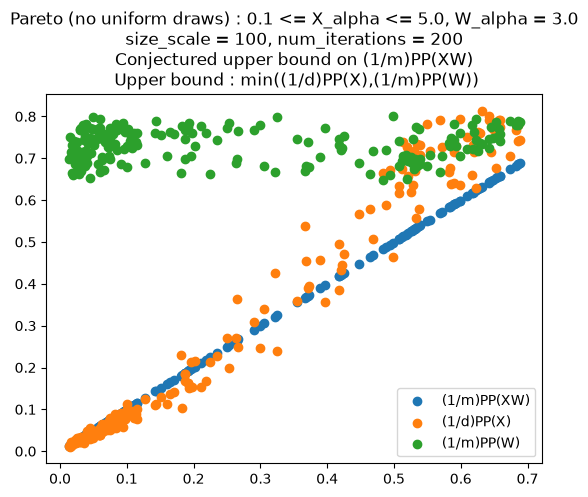


 (1/m) PP(XW) / ((1/d) PP(X) * (1/m) PP(W)) 
shape : (200,)
min : 0.9870828852287262
max : 2.563928811814994
sum : 288.38667356605856
mean : 1.4419333678302928
std : 0.28995125614468353
norm : 20.800209461456344


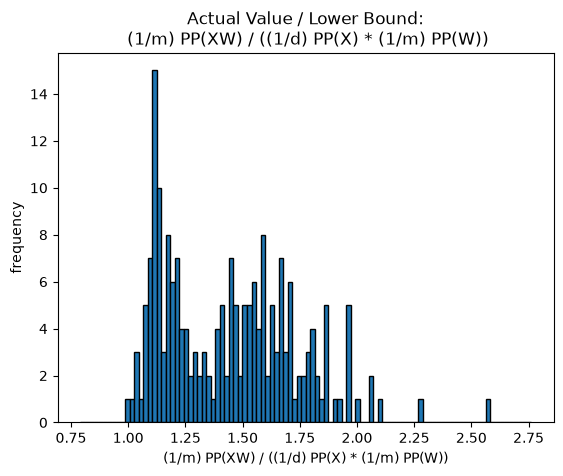


 min{(1/d)PP(X),(1/m)PP(W)} / (1/m) PP(XW) 
shape : (200,)
min : 0.5067999709012926
max : 1.4712947487764698
sum : 196.30189598339382
mean : 0.9815094799169691
std : 0.2002641655363474
norm : 14.166626946205994


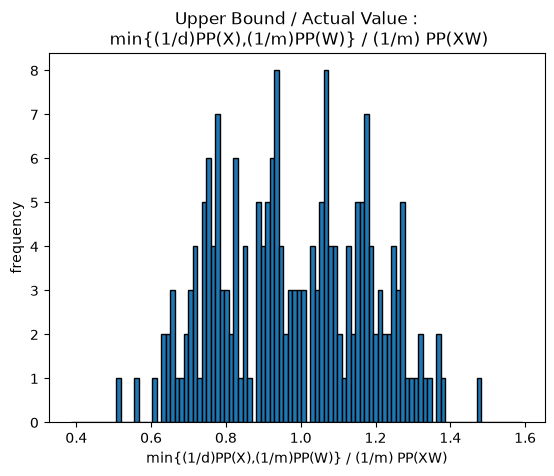

In [17]:
this_prefix = "Pareto (no uniform draws) : " + str(min_X_alpha) + " <= X_alpha <= " + str(max_X_alpha) + ", W_alpha = " + str(W_alpha) + "\n"
this_prefix += "size_scale = " + str(size_scale) + ", num_iterations = " + str(num_iterations) + "\n"
pp_dim_XW_experiment_plot_one(xx_pareto_no_ud_x_a_01_50_w_a_30_ss_100_ni_200, this_prefix)

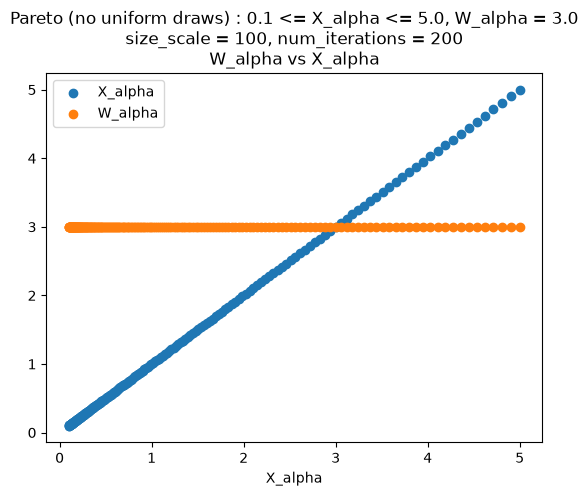

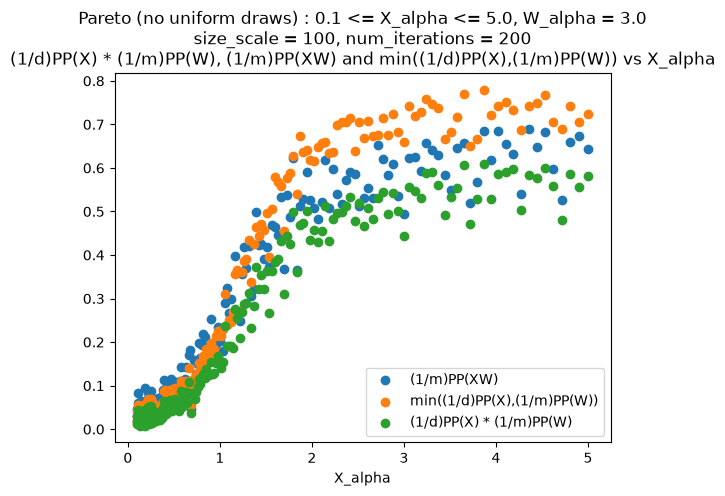

In [19]:
this_prefix = "Pareto (no uniform draws) : " + str(min_X_alpha) + " <= X_alpha <= " + str(max_X_alpha) + ", W_alpha = " + str(W_alpha) + "\n"
this_prefix += "size_scale = " + str(size_scale) + ", num_iterations = " + str(num_iterations) + "\n"
xx_pareto_no_ud_x_a_01_50_w_a_30_ss_100_ni_200["plt_vs_X_alpha"] = True
xx_pareto_no_ud_x_a_01_50_w_a_30_ss_100_ni_200["plt_vs_W_alpha"] = False
pp_dim_XW_experiment_pareto_plot(xx_pareto_no_ud_x_a_01_50_w_a_30_ss_100_ni_200, this_prefix)

# 1.3 Pareto - X_alpha varies between 0.1 and 5.0, W_alpha = X_alpha - no uniform draws

In [20]:
this_config = pp.pp_dim_XW_experiment_get_default_config()

num_iterations = 200
size_scale = 100

this_config["num_iterations"] = num_iterations 
this_config["use_pareto"] = True 
this_config["size_scale"] = size_scale
this_config["column_demean"] = True

min_X_alpha = 0.1
max_X_alpha = 5.0
pareto_X_alpha_vals = min_X_alpha * np.exp(math.log(max_X_alpha / min_X_alpha) * np.linspace(0, 1, num=num_iterations))
#X_alpha = 3.0
#pareto_X_alpha_vals = X_alpha * np.ones(num_iterations)

#min_W_alpha = 0.1
#max_W_alpha = 5.0
#pareto_W_alpha_vals = min_W_alpha * np.exp(math.log(max_W_alpha / min_W_alpha) * np.linspace(0, 1, num=num_iterations))
#W_alpha = 3.0
#pareto_W_alpha_vals = W_alpha * np.ones(num_iterations)
pareto_W_alpha_vals = pareto_X_alpha_vals

this_config["pareto_X_alpha_vals"] = pareto_X_alpha_vals
this_config["pareto_W_alpha_vals"] = pareto_W_alpha_vals
this_config["pareto_uniform_draws"] = False

xx_pareto_no_ud_x_a_eq_w_a_01_50_ss_100_ni_200 = pp.pp_dim_XW_experiment(this_config)

0 N =  185 , d =  135 , m =  127
using Pareto
** calculate_nu_cpu ** running on CPU
0 X.shape =  (185, 135) , dim_X =  135
** calculate_nu_cpu ** running on CPU
0 W.shape =  (135, 127) , dim_W =  127
** calculate_nu_cpu ** running on CPU
0 XW.shape =  (185, 127) , dim_XW =  127
0 69.13494112090238 0.9655899965567846
0 PP(XW) =  1.0000001012703992 , Tr(XW)^2 / Tr( (XW)^t (XW)) =  5.7374211141067686e-05
1 N =  294 , d =  234 , m =  152
using Pareto
** calculate_nu_cpu ** running on CPU
1 X.shape =  (294, 234) , dim_X =  234
** calculate_nu_cpu ** running on CPU
1 W.shape =  (234, 152) , dim_W =  152
** calculate_nu_cpu ** running on CPU
1 XW.shape =  (294, 152) , dim_XW =  152
1 9.459997704864335 2.4686277504895138
1 PP(XW) =  1.1881871124317025 , Tr(XW)^2 / Tr( (XW)^t (XW)) =  1.96117714833882e-06
2 N =  294 , d =  207 , m =  160
using Pareto
** calculate_nu_cpu ** running on CPU
2 X.shape =  (294, 207) , dim_X =  207
** calculate_nu_cpu ** running on CPU
2 W.shape =  (207, 160) , dim_W

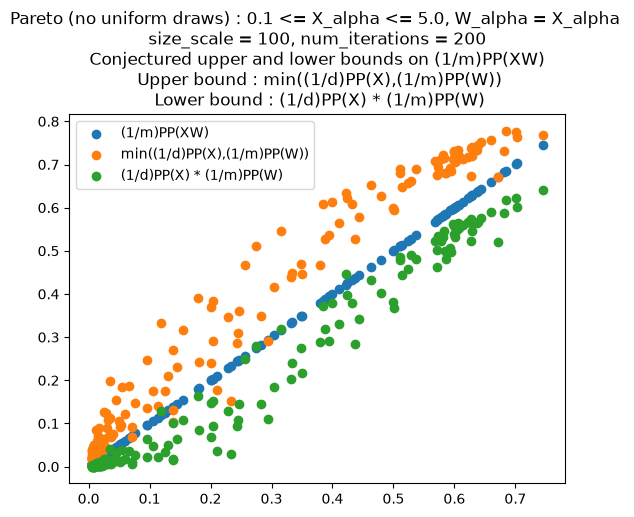

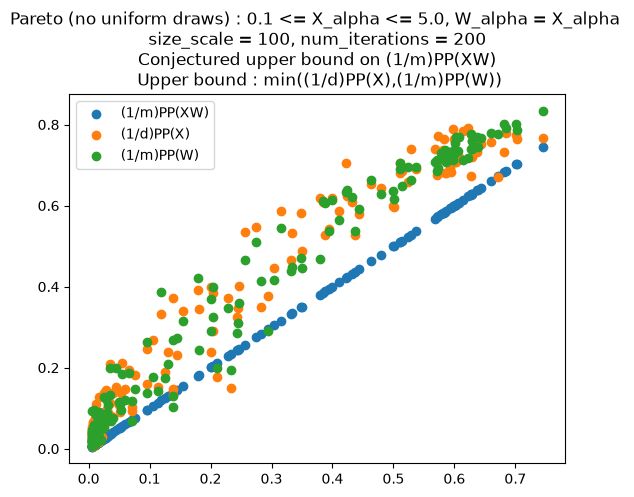


 (1/m) PP(XW) / ((1/d) PP(X) * (1/m) PP(W)) 
shape : (200,)
min : 0.8477265388623444
max : 118.41200876210746
sum : 1311.8249689050272
mean : 6.559124844525136
std : 11.552759792145345
norm : 187.87675616801405


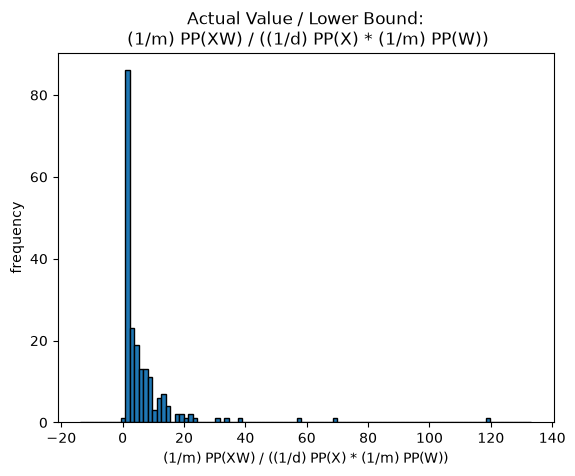


 min{(1/d)PP(X),(1/m)PP(W)} / (1/m) PP(XW) 
shape : (200,)
min : 0.6484681462577502
max : 7.057512897038387
sum : 459.5152650820148
mean : 2.2975763254100743
std : 1.3792395251360272
norm : 37.89764805045905


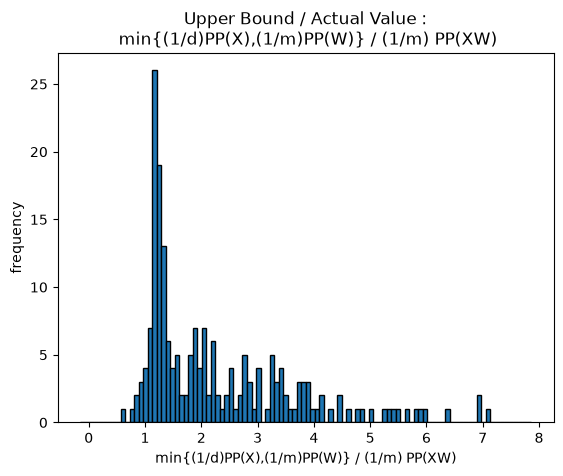

In [21]:
this_prefix = "Pareto (no uniform draws) : " + str(min_X_alpha) + " <= X_alpha <= " + str(max_X_alpha) + ", W_alpha = X_alpha \n"
this_prefix += "size_scale = " + str(size_scale) + ", num_iterations = " + str(num_iterations) + "\n"
pp_dim_XW_experiment_plot_one(xx_pareto_no_ud_x_a_eq_w_a_01_50_ss_100_ni_200, this_prefix)

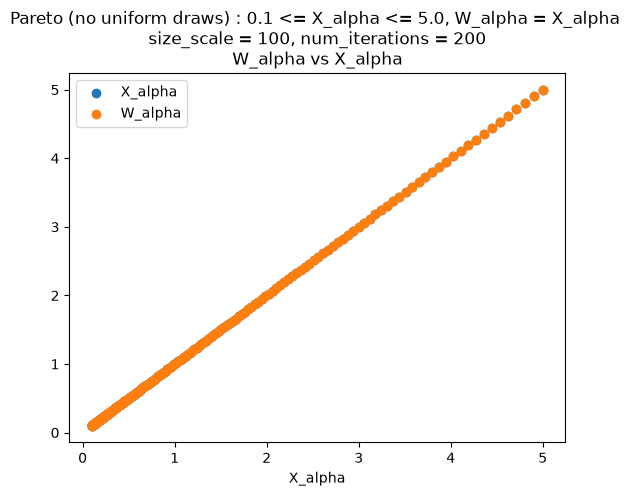

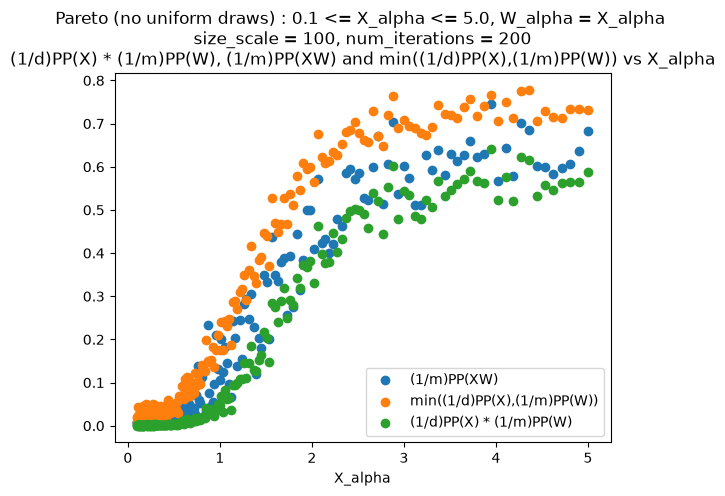

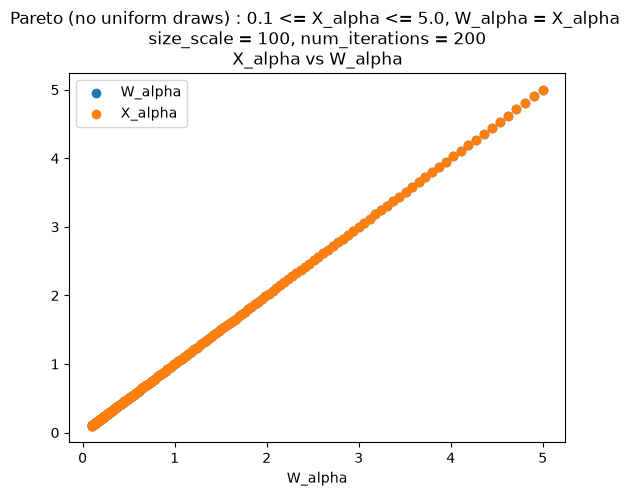

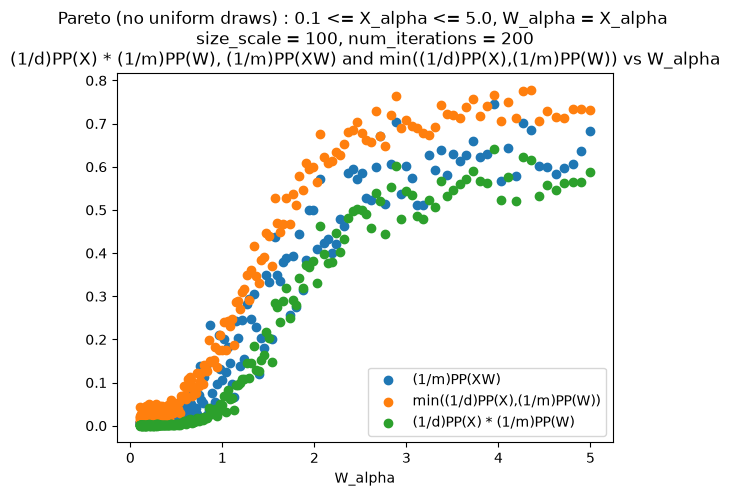

In [22]:
this_prefix = "Pareto (no uniform draws) : " + str(min_X_alpha) + " <= X_alpha <= " + str(max_X_alpha) + ", W_alpha = X_alpha \n"
this_prefix += "size_scale = " + str(size_scale) + ", num_iterations = " + str(num_iterations) + "\n"
xx_pareto_no_ud_x_a_eq_w_a_01_50_ss_100_ni_200["plt_vs_X_alpha"] = True
xx_pareto_no_ud_x_a_eq_w_a_01_50_ss_100_ni_200["plt_vs_W_alpha"] = True
pp_dim_XW_experiment_pareto_plot(xx_pareto_no_ud_x_a_eq_w_a_01_50_ss_100_ni_200, this_prefix)

# 1.3 Pareto - X_alpha and W_alpha both vary between 0.1 and 5.0, no correlation between them - no uniform draws

In [25]:
# Create a random generator object
rng = np.random.default_rng()

# Permute an integer range
permuted_range = rng.permutation(5)

print(permuted_range)

this_config = pp.pp_dim_XW_experiment_get_default_config()

num_iterations = 200
size_scale = 100

this_config["num_iterations"] = num_iterations 
this_config["use_pareto"] = True 
this_config["size_scale"] = size_scale
this_config["column_demean"] = True

min_X_alpha = 0.1
max_X_alpha = 5.0
pareto_X_alpha_vals = min_X_alpha * np.exp(math.log(max_X_alpha / min_X_alpha) * np.linspace(0, 1, num=num_iterations))
#X_alpha = 3.0
#pareto_X_alpha_vals = X_alpha * np.ones(num_iterations)

min_W_alpha = 0.1
max_W_alpha = 5.0
initial_pareto_W_alpha_vals = min_W_alpha * np.exp(math.log(max_W_alpha / min_W_alpha) * np.linspace(0, 1, num=num_iterations))

permuted_range = rng.permutation(len(initial_pareto_W_alpha_vals))

pareto_W_alpha_vals = np.zeros(len(initial_pareto_W_alpha_vals))
for i in range(len(pareto_W_alpha_vals)):
    this_index = permuted_range[i]
    pareto_W_alpha_vals[i] = initial_pareto_W_alpha_vals[this_index]
    
#W_alpha = 3.0
#pareto_W_alpha_vals = W_alpha * np.ones(num_iterations)
#pareto_W_alpha_vals = pareto_X_alpha_vals

this_config["pareto_X_alpha_vals"] = pareto_X_alpha_vals
this_config["pareto_W_alpha_vals"] = pareto_W_alpha_vals
this_config["pareto_uniform_draws"] = False

xx_pareto_no_ud_x_a_w_a_01_50_ss_100_ni_200 = pp.pp_dim_XW_experiment(this_config)

[4 2 0 1 3]
0 N =  203 , d =  185 , m =  106
using Pareto
** calculate_nu_cpu ** running on CPU
0 X.shape =  (203, 185) , dim_X =  185
** calculate_nu_cpu ** running on CPU
0 W.shape =  (185, 106) , dim_W =  106
** calculate_nu_cpu ** running on CPU
0 XW.shape =  (203, 106) , dim_XW =  106
0 9.289228506687484 2.0005445062731693
0 PP(XW) =  1.7277762215438541 , Tr(XW)^2 / Tr( (XW)^t (XW)) =  0.0005568771339180148
1 N =  291 , d =  272 , m =  189
using Pareto
** calculate_nu_cpu ** running on CPU
1 X.shape =  (291, 272) , dim_X =  272
** calculate_nu_cpu ** running on CPU
1 W.shape =  (272, 189) , dim_W =  189
** calculate_nu_cpu ** running on CPU
1 XW.shape =  (291, 189) , dim_XW =  189
1 1.8205369407922516 0.6999120449749263
1 PP(XW) =  5.974357682635144 , Tr(XW)^2 / Tr( (XW)^t (XW)) =  0.0002800970670070804
2 N =  323 , d =  287 , m =  190
using Pareto
** calculate_nu_cpu ** running on CPU
2 X.shape =  (323, 287) , dim_X =  287
** calculate_nu_cpu ** running on CPU
2 W.shape =  (287, 

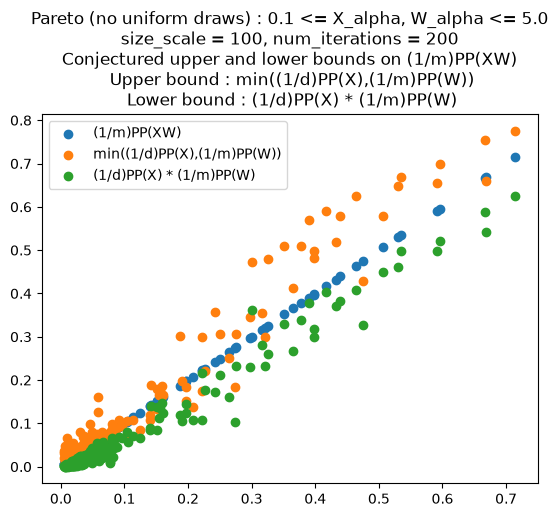

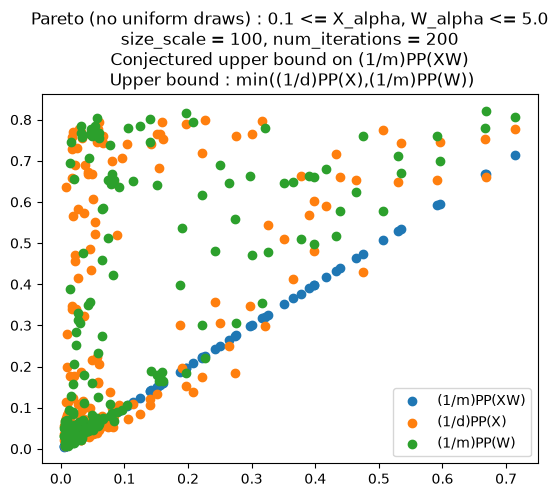


 (1/m) PP(XW) / ((1/d) PP(X) * (1/m) PP(W)) 
shape : (200,)
min : 0.8300267539723987
max : 38.07139280850448
sum : 854.3302202063521
mean : 4.271651101031761
std : 5.438305486906567
norm : 97.7979240044122


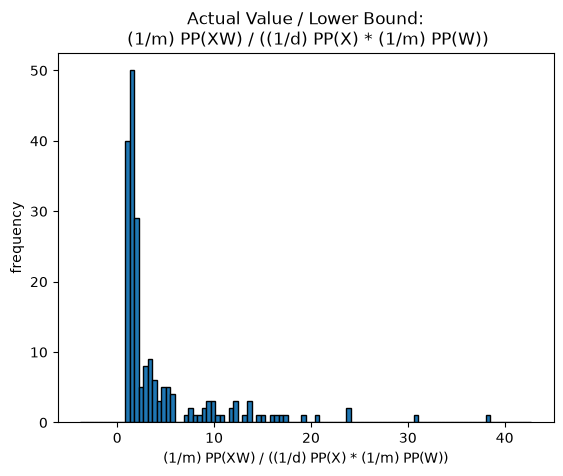


 min{(1/d)PP(X),(1/m)PP(W)} / (1/m) PP(XW) 
shape : (200,)
min : 0.6424984096406609
max : 7.4298734207450465
sum : 318.0749043937709
mean : 1.5903745219688545
std : 1.2183995564097028
norm : 28.33297936746866


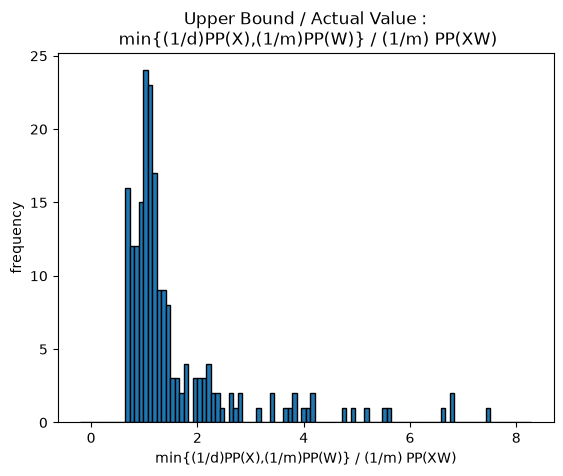

In [26]:
this_prefix = "Pareto (no uniform draws) : " + str(min_X_alpha) + " <= X_alpha, W_alpha <= " + str(max_X_alpha) + "\n"
this_prefix += "size_scale = " + str(size_scale) + ", num_iterations = " + str(num_iterations) + "\n"
pp_dim_XW_experiment_plot_one(xx_pareto_no_ud_x_a_w_a_01_50_ss_100_ni_200, this_prefix)

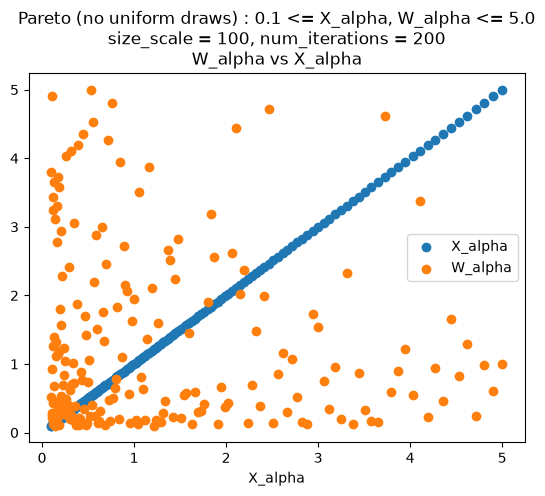

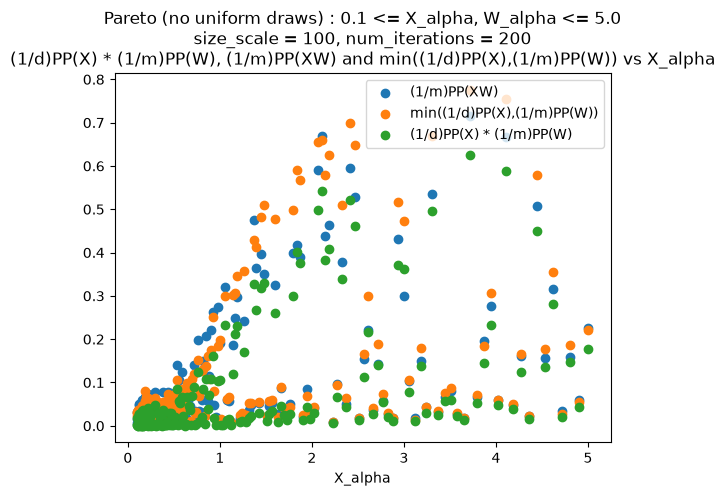

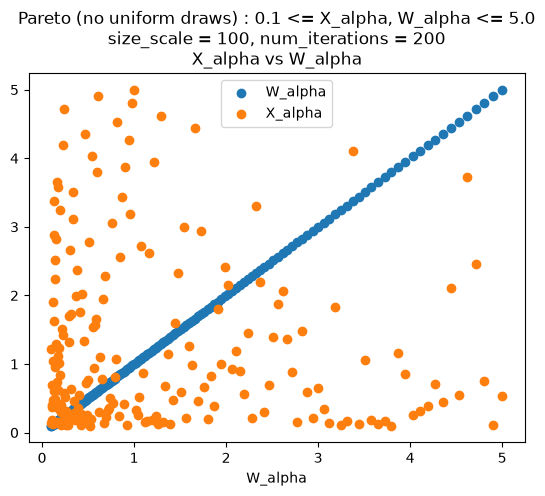

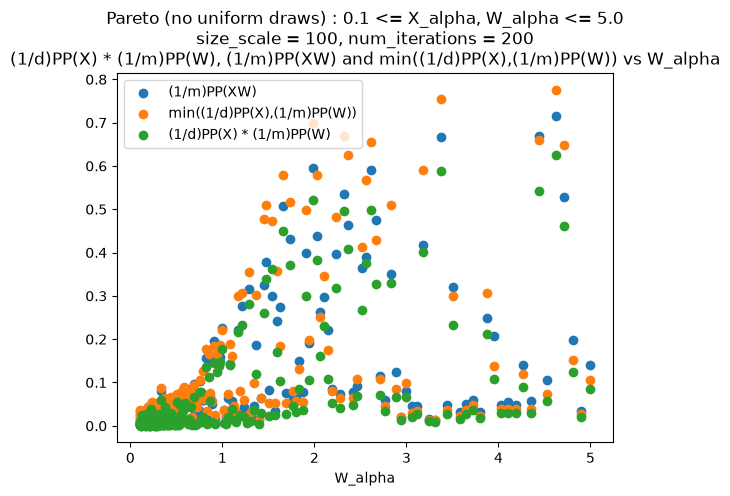

In [27]:
this_prefix = "Pareto (no uniform draws) : " + str(min_X_alpha) + " <= X_alpha, W_alpha <= " + str(max_X_alpha) + "\n"
this_prefix += "size_scale = " + str(size_scale) + ", num_iterations = " + str(num_iterations) + "\n"
xx_pareto_no_ud_x_a_w_a_01_50_ss_100_ni_200["plt_vs_X_alpha"] = True
xx_pareto_no_ud_x_a_w_a_01_50_ss_100_ni_200["plt_vs_W_alpha"] = True
pp_dim_XW_experiment_pareto_plot(xx_pareto_no_ud_x_a_w_a_01_50_ss_100_ni_200, this_prefix)

# 1.3 Pareto - X_alpha and W_alpha both vary between 0.1 and 5.0, no correlation between them - no uniform draws (version 2)

In [29]:
# Create a random generator object
rng = np.random.default_rng()

# Permute an integer range
permuted_range = rng.permutation(5)

print(permuted_range)

this_config = pp.pp_dim_XW_experiment_get_default_config()

num_iterations = 200
size_scale = 100

this_config["num_iterations"] = num_iterations 
this_config["use_pareto"] = True 
this_config["size_scale"] = size_scale
this_config["column_demean"] = True

min_X_alpha = 0.1
max_X_alpha = 5.0
pareto_X_alpha_vals = np.linspace(min_X_alpha, max_X_alpha, num=num_iterations)
#X_alpha = 3.0
#pareto_X_alpha_vals = X_alpha * np.ones(num_iterations)

min_W_alpha = 0.1
max_W_alpha = 5.0
initial_pareto_W_alpha_vals = np.linspace(min_W_alpha, max_W_alpha, num=num_iterations)

permuted_range = rng.permutation(len(initial_pareto_W_alpha_vals))

pareto_W_alpha_vals = np.zeros(len(initial_pareto_W_alpha_vals))
for i in range(len(pareto_W_alpha_vals)):
    this_index = permuted_range[i]
    pareto_W_alpha_vals[i] = initial_pareto_W_alpha_vals[this_index]
    
#W_alpha = 3.0
#pareto_W_alpha_vals = W_alpha * np.ones(num_iterations)
#pareto_W_alpha_vals = pareto_X_alpha_vals

this_config["pareto_X_alpha_vals"] = pareto_X_alpha_vals
this_config["pareto_W_alpha_vals"] = pareto_W_alpha_vals
this_config["pareto_uniform_draws"] = False

xx_pareto_no_ud_x_a_w_a_01_50_ss_100_ni_200_v2 = pp.pp_dim_XW_experiment(this_config)

[2 1 4 3 0]
0 N =  276 , d =  246 , m =  167
using Pareto
** calculate_nu_cpu ** running on CPU
0 X.shape =  (276, 246) , dim_X =  246
** calculate_nu_cpu ** running on CPU
0 W.shape =  (246, 167) , dim_W =  167
** calculate_nu_cpu ** running on CPU
0 XW.shape =  (276, 167) , dim_XW =  167
0 1.7524572315139788 0.715794024256045
0 PP(XW) =  10.212109576428762 , Tr(XW)^2 / Tr( (XW)^t (XW)) =  0.00014625245903973887
1 N =  365 , d =  277 , m =  185
using Pareto
** calculate_nu_cpu ** running on CPU
1 X.shape =  (365, 277) , dim_X =  277
** calculate_nu_cpu ** running on CPU
1 W.shape =  (277, 185) , dim_W =  185
** calculate_nu_cpu ** running on CPU
1 XW.shape =  (365, 185) , dim_XW =  185
1 1.636915671843171 0.7792342075218275
1 PP(XW) =  11.762292836660977 , Tr(XW)^2 / Tr( (XW)^t (XW)) =  0.0038082713436486193
2 N =  260 , d =  212 , m =  171
using Pareto
** calculate_nu_cpu ** running on CPU
2 X.shape =  (260, 212) , dim_X =  212
** calculate_nu_cpu ** running on CPU
2 W.shape =  (212,

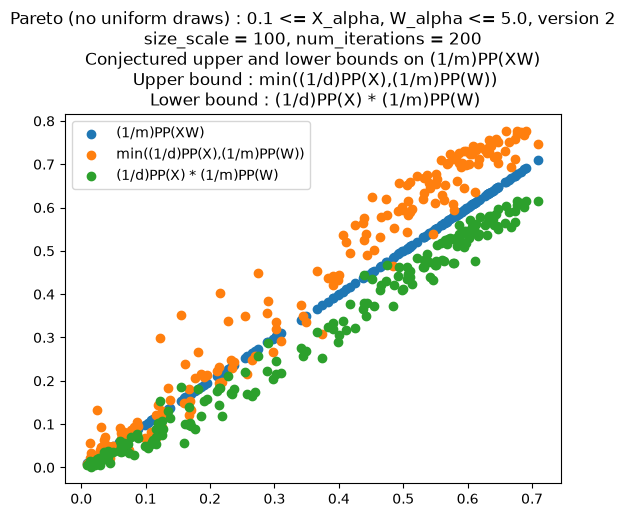

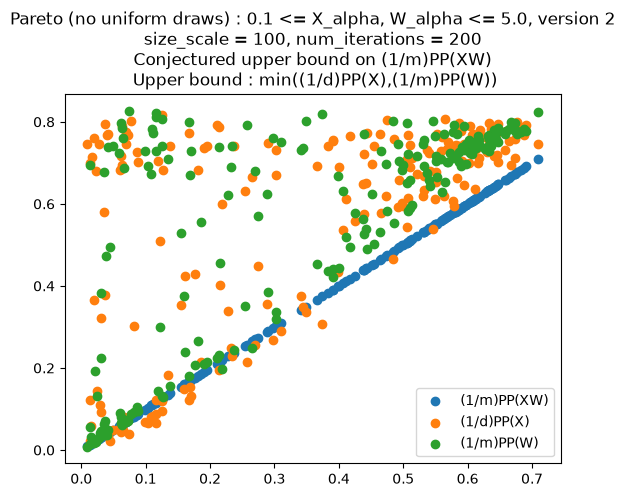


 (1/m) PP(XW) / ((1/d) PP(X) * (1/m) PP(W)) 
shape : (200,)
min : 0.7992872706387966
max : 8.211255075371017
sum : 276.4194168203128
mean : 1.3820970841015638
std : 0.7367848405343758
norm : 22.14969187651743


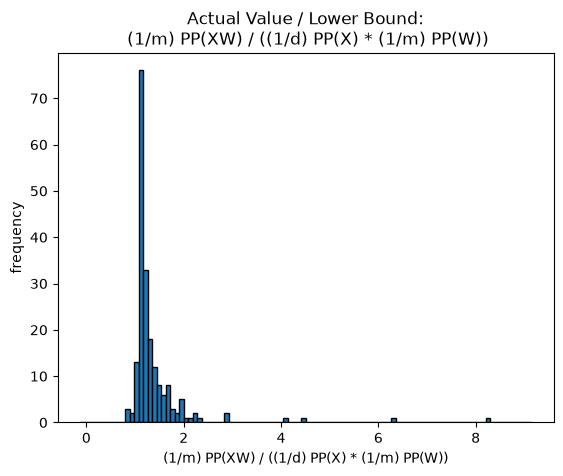


 min{(1/d)PP(X),(1/m)PP(W)} / (1/m) PP(XW) 
shape : (200,)
min : 0.49986732282270274
max : 5.574469366545716
sum : 237.82855181573717
mean : 1.1891427590786858
std : 0.4685271699146692
norm : 18.07527709562163


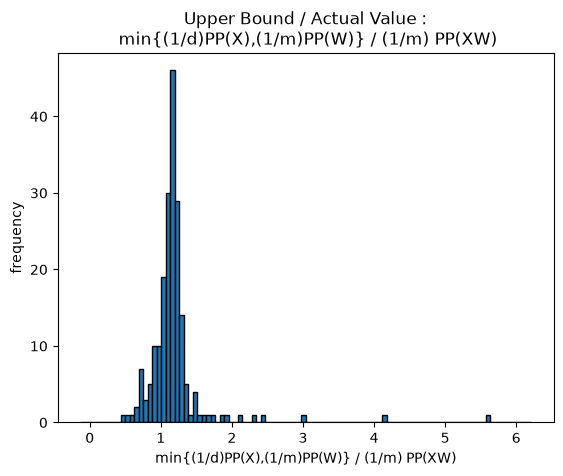

In [30]:
this_prefix = "Pareto (no uniform draws) : " + str(min_X_alpha) + " <= X_alpha, W_alpha <= " + str(max_X_alpha) + ", version 2\n"
this_prefix += "size_scale = " + str(size_scale) + ", num_iterations = " + str(num_iterations) + "\n"
pp_dim_XW_experiment_plot_one(xx_pareto_no_ud_x_a_w_a_01_50_ss_100_ni_200_v2, this_prefix)

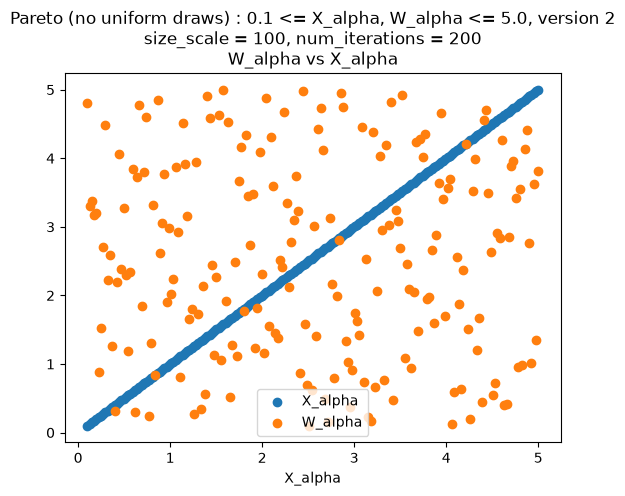

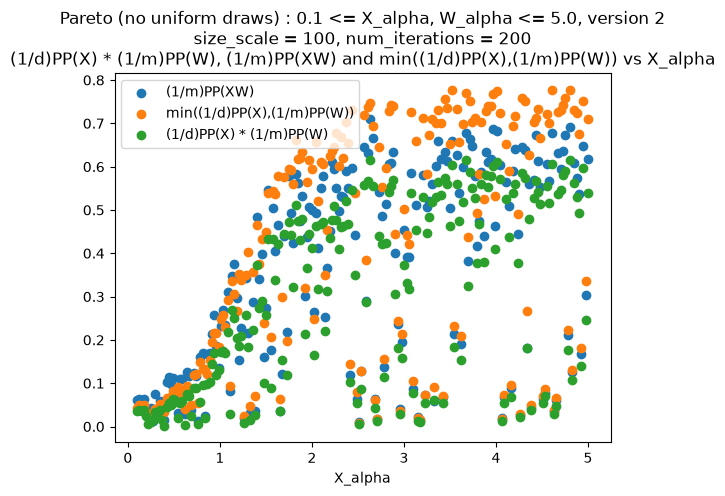

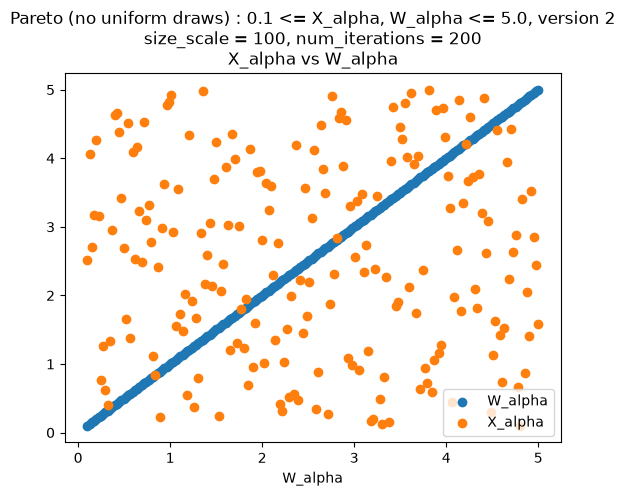

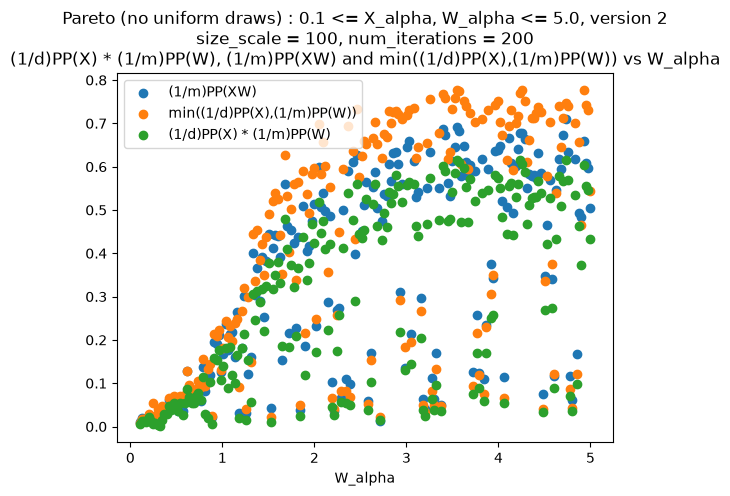

In [31]:
this_prefix = "Pareto (no uniform draws) : " + str(min_X_alpha) + " <= X_alpha, W_alpha <= " + str(max_X_alpha) + ", version 2\n"
this_prefix += "size_scale = " + str(size_scale) + ", num_iterations = " + str(num_iterations) + "\n"
xx_pareto_no_ud_x_a_w_a_01_50_ss_100_ni_200_v2["plt_vs_X_alpha"] = True
xx_pareto_no_ud_x_a_w_a_01_50_ss_100_ni_200_v2["plt_vs_W_alpha"] = True
pp_dim_XW_experiment_pareto_plot(xx_pareto_no_ud_x_a_w_a_01_50_ss_100_ni_200_v2, this_prefix)

# 1.4 Random - mix uniform, normal, Pareto

In [34]:
# Create a random generator object
rng = np.random.default_rng()

# Permute an integer range
permuted_range = rng.permutation(5)

print(permuted_range)

this_config = pp.pp_dim_XW_experiment_get_default_config()

num_iterations = 200
size_scale = 100

this_config["num_iterations"] = num_iterations 
this_config["random_mode"] = True 
this_config["size_scale"] = size_scale
this_config["column_demean"] = True

min_X_alpha = 0.1
max_X_alpha = 5.0
pareto_X_alpha_vals = np.linspace(min_X_alpha, max_X_alpha, num=num_iterations)
#X_alpha = 3.0
#pareto_X_alpha_vals = X_alpha * np.ones(num_iterations)

min_W_alpha = 0.1
max_W_alpha = 5.0
initial_pareto_W_alpha_vals = np.linspace(min_W_alpha, max_W_alpha, num=num_iterations)

permuted_range = rng.permutation(len(initial_pareto_W_alpha_vals))

pareto_W_alpha_vals = np.zeros(len(initial_pareto_W_alpha_vals))
for i in range(len(pareto_W_alpha_vals)):
    this_index = permuted_range[i]
    pareto_W_alpha_vals[i] = initial_pareto_W_alpha_vals[this_index]
    
#W_alpha = 3.0
#pareto_W_alpha_vals = W_alpha * np.ones(num_iterations)
#pareto_W_alpha_vals = pareto_X_alpha_vals

this_config["pareto_X_alpha_vals"] = pareto_X_alpha_vals
this_config["pareto_W_alpha_vals"] = pareto_W_alpha_vals
this_config["pareto_uniform_draws"] = False

xx_random_ss_100_ni_200 = pp.pp_dim_XW_experiment(this_config)

[4 2 3 1 0]
0 N =  272 , d =  231 , m =  187
using random_mode
using normal
** calculate_nu_cpu ** running on CPU
0 X.shape =  (272, 231) , dim_X =  231
** calculate_nu_cpu ** running on CPU
0 W.shape =  (231, 187) , dim_W =  187
** calculate_nu_cpu ** running on CPU
0 XW.shape =  (272, 187) , dim_XW =  187
0 1.0914623449325838 1.1723809174132123
0 PP(XW) =  122.4101164140703 , Tr(XW)^2 / Tr( (XW)^t (XW)) =  7.346268783710007e-05
1 N =  191 , d =  183 , m =  168
using random_mode
using uniform
** calculate_nu_cpu ** running on CPU
1 X.shape =  (191, 183) , dim_X =  183
** calculate_nu_cpu ** running on CPU
1 W.shape =  (183, 168) , dim_W =  168
** calculate_nu_cpu ** running on CPU
1 XW.shape =  (191, 168) , dim_XW =  168
1 1.0908268764447733 1.226778750995555
1 PP(XW) =  99.67319569432514 , Tr(XW)^2 / Tr( (XW)^t (XW)) =  5.314890932792169e-05
2 N =  302 , d =  263 , m =  172
using random_mode
using normal
** calculate_nu_cpu ** running on CPU
2 X.shape =  (302, 263) , dim_X =  263
** 

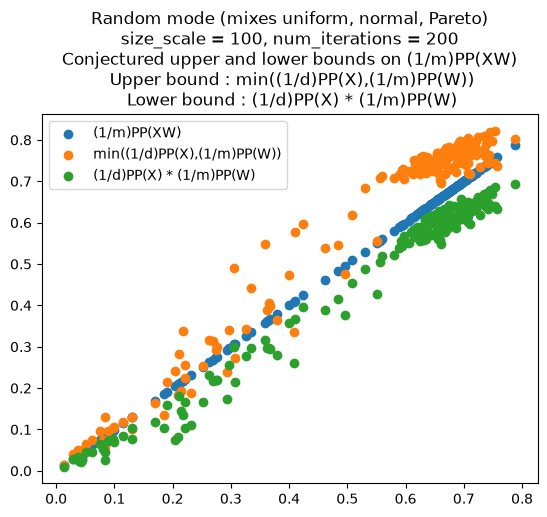

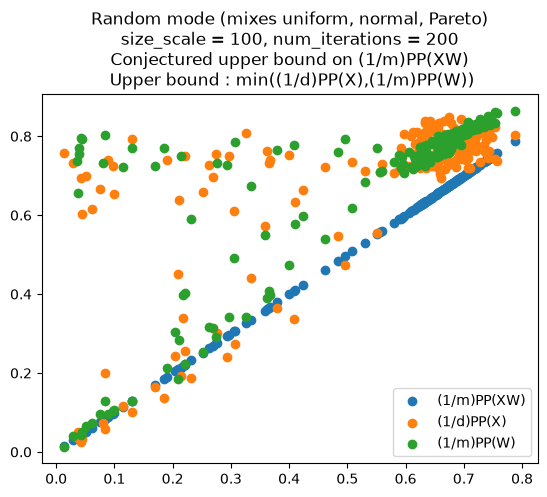


 (1/m) PP(XW) / ((1/d) PP(X) * (1/m) PP(W)) 
shape : (200,)
min : 0.9987954519531693
max : 3.235366961555358
sum : 240.2051303968272
mean : 1.201025651984136
std : 0.2732912080643307
norm : 17.419246258832096


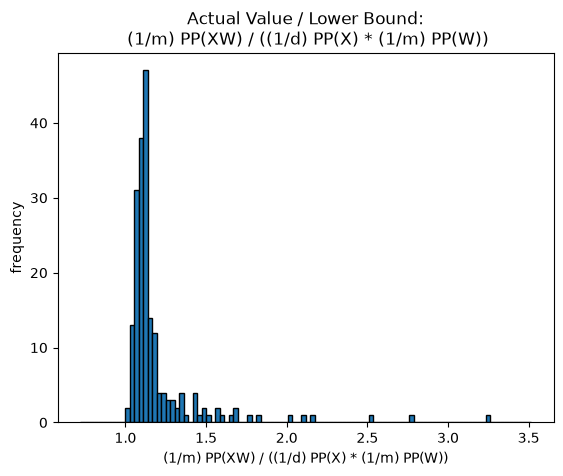


 min{(1/d)PP(X),(1/m)PP(W)} / (1/m) PP(XW) 
shape : (200,)
min : 0.6236991868918165
max : 1.605885759342708
sum : 223.24639697228716
mean : 1.1162319848614357
std : 0.12914610099047066
norm : 15.891208635146299


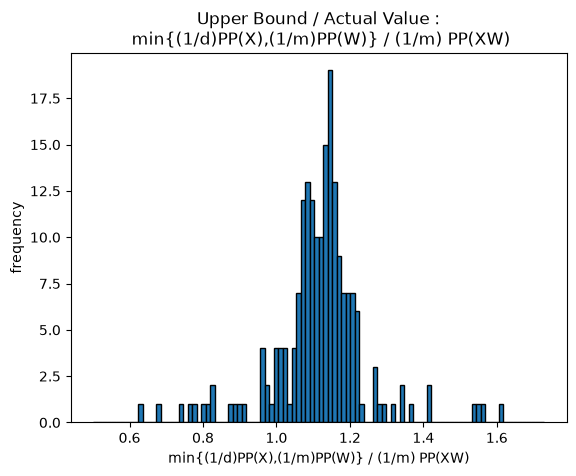

In [35]:
this_prefix = "Random mode (mixes uniform, normal, Pareto)\n"
this_prefix += "size_scale = " + str(size_scale) + ", num_iterations = " + str(num_iterations) + "\n"
pp_dim_XW_experiment_plot_one(xx_random_ss_100_ni_200, this_prefix)

In [ ]:
print(this_config)
print(xx)

In [6]:
def pp_dim_XW_experiment_plot_one(results_dict : dict, prefix : str):

    pp_dim_X_over_dim_X_vals = results_dict["pp_dim_X_over_dim_X_vals"] 
    pp_dim_W_over_dim_W_vals = results_dict["pp_dim_W_over_dim_W_vals"] 
    pp_dim_XW_over_dim_XW_vals = results_dict["pp_dim_XW_over_dim_XW_vals"] 
    conjectured_lower_bound_vals = results_dict["conjectured_lower_bound_vals"] 
    conjectured_upper_bound_vals = results_dict["conjectured_upper_bound_vals"] 
    actual_over_lower_vals = results_dict["actual_over_lower_vals"] 
    upper_over_actual_vals = results_dict["upper_over_actual_vals"]
    tr_XW_squared_over_tr_WtXtXW_vals = results_dict["tr_XW_squared_over_tr_WtXtXW_vals"] 

    this_title = prefix
    this_title += "Conjectured upper and lower bounds on (1/m)PP(XW)"
    this_title += "\n Upper bound : min((1/d)PP(X),(1/m)PP(W))"
    this_title += "\n Lower bound : (1/d)PP(X) * (1/m)PP(W)"
    plt.scatter(pp_dim_XW_over_dim_XW_vals, pp_dim_XW_over_dim_XW_vals, label = "(1/m)PP(XW)")
    plt.scatter(pp_dim_XW_over_dim_XW_vals, conjectured_upper_bound_vals, 
        label = "min((1/d)PP(X),(1/m)PP(W))")
    plt.scatter(pp_dim_XW_over_dim_XW_vals, conjectured_lower_bound_vals, 
        label = "(1/d)PP(X) * (1/m)PP(W)")
    plt.legend()
    plt.title(this_title)
    plt.show()

    this_title = prefix
    this_title += "Conjectured upper bound on (1/m)PP(XW)"
    this_title += "\n Upper bound : min((1/d)PP(X),(1/m)PP(W))"
    plt.scatter(pp_dim_XW_over_dim_XW_vals, pp_dim_XW_over_dim_XW_vals, label = "(1/m)PP(XW)")
    plt.scatter(pp_dim_XW_over_dim_XW_vals, pp_dim_X_over_dim_X_vals, label = "(1/d)PP(X)")
    plt.scatter(pp_dim_XW_over_dim_XW_vals, pp_dim_W_over_dim_W_vals, label = "(1/m)PP(W)")
    plt.legend()
    plt.title(this_title)
    plt.show()

    actual_over_lower_text = "(1/m) PP(XW) / ((1/d) PP(X) * (1/m) PP(W))"
    sep = "="*80
    print("\n", sep, "\n", actual_over_lower_text, "\n", sep)
    pp.display_stats(actual_over_lower_vals)

    rescale_factor=1.0
    x_label = actual_over_lower_text
    y_label = "frequency"
    title = "Actual Value / Lower Bound:\n " + actual_over_lower_text
    pp.plot_histogram(actual_over_lower_vals, rescale_factor, x_label, y_label, title)
    #pp.display_stats

    upper_over_actual_text = "min{(1/d)PP(X),(1/m)PP(W)} / (1/m) PP(XW)"
    sep = "="*80
    print("\n", sep, "\n", upper_over_actual_text, "\n", sep)
    pp.display_stats(upper_over_actual_vals)

    rescale_factor=1.0
    x_label = upper_over_actual_text
    y_label = "frequency"
    title = "Upper Bound / Actual Value :\n " + upper_over_actual_text
    pp.plot_histogram(upper_over_actual_vals, rescale_factor, x_label, y_label, title)
    

In [7]:

def pp_dim_XW_experiment_pareto_plot(this_results_dict : dict, prefix : str):

    pp_dim_X_over_dim_X_vals = this_results_dict["pp_dim_X_over_dim_X_vals"] 
    pp_dim_W_over_dim_W_vals = this_results_dict["pp_dim_W_over_dim_W_vals"] 
    pp_dim_XW_over_dim_XW_vals = this_results_dict["pp_dim_XW_over_dim_XW_vals"] 
    conjectured_lower_bound_vals = this_results_dict["conjectured_lower_bound_vals"] 
    conjectured_upper_bound_vals = this_results_dict["conjectured_upper_bound_vals"] 
    actual_over_lower_vals = this_results_dict["actual_over_lower_vals"] 
    upper_over_actual_vals = this_results_dict["upper_over_actual_vals"]
    tr_XW_squared_over_tr_WtXtXW_vals = this_results_dict["tr_XW_squared_over_tr_WtXtXW_vals"] 
    pareto_X_alpha_vals = this_results_dict["pareto_X_alpha_vals"]
    pareto_W_alpha_vals = this_results_dict["pareto_W_alpha_vals"]

    plt_vs_X_alpha = this_results_dict["plt_vs_X_alpha"]
    plt_vs_W_alpha = this_results_dict["plt_vs_W_alpha"]

    if plt_vs_X_alpha:
        this_title = prefix
        this_title += "W_alpha vs X_alpha"
        plt.scatter(pareto_X_alpha_vals, pareto_X_alpha_vals, label = "X_alpha")
        plt.scatter(pareto_X_alpha_vals, pareto_W_alpha_vals, label = "W_alpha")
        plt.xlabel("X_alpha")
        plt.legend()
        plt.title(this_title)
        plt.show()

        this_title = prefix
        this_title += "(1/d)PP(X) * (1/m)PP(W), (1/m)PP(XW) and min((1/d)PP(X),(1/m)PP(W)) vs X_alpha"
        plt.scatter(pareto_X_alpha_vals, pp_dim_XW_over_dim_XW_vals, label = "(1/m)PP(XW)")
        plt.scatter(pareto_X_alpha_vals, conjectured_upper_bound_vals, 
            label = "min((1/d)PP(X),(1/m)PP(W))")
        plt.scatter(pareto_X_alpha_vals, conjectured_lower_bound_vals, 
            label = "(1/d)PP(X) * (1/m)PP(W)")
        plt.xlabel("X_alpha")
        plt.legend()
        plt.title(this_title)
        plt.show()
        
    
    if plt_vs_W_alpha:
        this_title = prefix
        this_title += "X_alpha vs W_alpha"
        plt.scatter(pareto_W_alpha_vals, pareto_W_alpha_vals, label = "W_alpha")
        plt.scatter(pareto_W_alpha_vals, pareto_X_alpha_vals, label = "X_alpha")
        plt.xlabel("W_alpha")
        plt.legend()
        plt.title(this_title)
        plt.show()

        this_title = prefix
        this_title += "(1/d)PP(X) * (1/m)PP(W), (1/m)PP(XW) and min((1/d)PP(X),(1/m)PP(W)) vs W_alpha"
        plt.scatter(pareto_W_alpha_vals, pp_dim_XW_over_dim_XW_vals, label = "(1/m)PP(XW)")
        plt.scatter(pareto_W_alpha_vals, conjectured_upper_bound_vals, 
            label = "min((1/d)PP(X),(1/m)PP(W))")
        plt.scatter(pareto_W_alpha_vals, conjectured_lower_bound_vals, 
            label = "(1/d)PP(X) * (1/m)PP(W)")
        plt.xlabel("W_alpha")
        plt.legend()
        plt.title(this_title)
        plt.show()

        